# ⚡ Electricity Load Forecasting — ARIMA / SARIMA / SARIMAX Full Pipeline
**Dataset:** `continuous_dataset.csv` (2015–2020, hourly)
---
### 🎯 Forecasting Goal
| | |
|---|---|
| **Horizon 1 (short)** | **6-hour ahead** forecast (seq2seq, 6 steps) |
| **Horizon 2 (medium)** | **12-hour ahead** forecast (seq2seq, 12 steps) |
| **Horizon 3 (long)** | **24-hour ahead** forecast (seq2seq, 24 steps) |
| **Output strategy** | **Sequence-to-sequence** — all H steps predicted simultaneously |
| **Horizons compared** | 6 h vs 12 h vs 24 h: accuracy degradation across the daily cycle |
| **History window** | 24 hours lookback |

---
### 📋 ML Pipeline (13 Steps)
```
EDA ──► Preprocessing ──► Feature Engineering ──► Model Training (CV) ──► Model Testing ──► Analysis
                                                          ▲                      │
                                                          └──── Hyperparameter ◄─┘
                                                                  Tuning
```

| Step | Content |
|---|---|
| 1 | EDA — overview, seasonality, ADF stationarity, ACF/PACF |
| 2 | Data Preprocessing |
| 3 | Feature Engineering (lag, cyclical, rolling, differencing) |
| 4 | **4-Fold Year-Based Expanding Window CV + Held-out Test Set (2020 Jan–Feb)** |
| 5 | Model Justification — **Persistence** → ARIMA → SARIMA → SARIMAX |
| 6 | Hyperparameter Grid Search (SARIMA configurations) |
| 7 | Model Training — Persistence / ARIMA / SARIMA / SARIMAX across all CV folds |
| 8 | Model Evaluation — cross-fold MAE / RMSE / MAPE + **Final Test (2020)** |
| 9 | Multi-Horizon Seq2Seq Evaluation on TEST SET (**6 h**, **12 h**, **24 h** ahead) |
| 10 | Exogenous Variable Analysis — All Folds |
| 11 | Robustness + Wilcoxon Signed-Rank Test |
| 12 | Overfitting Analysis — Train vs Validation Behaviour |
| 13 | Error Analysis + Feature Importance (SHAP) |

---
### 📏 Baselines (Essential)
In addition to classical/deep learning models, this pipeline includes appropriate baselines required for
any credible time-series forecasting study:

| Baseline | What it predicts | Why included |
|---|---|---|
| **Persistence (naïve)** | ŷ(t+h) = y(t) — the last observed value is carried forward for all H steps | Absolute lower-bar benchmark. Any model that cannot beat persistence provides no value. |
| **Seasonal naïve** | ŷ(t+h) = y(t+h−24) — "same hour yesterday" | Captures the dominant daily cycle without any modelling. A strong baseline for hourly load data. |

> Every trained model (ARIMA, SARIMA, SARIMAX) **must outperform both persistence baselines** on
> RMSE, MAE, and MAPE to be considered useful.

---
### 🔁 Cross-Validation Strategy (Walk-Forward, Year-Based Expanding Window)

**4 CV folds (for model selection) + 1 held-out TEST set (for final evaluation)**

```
CV1 : Train 2015            → Validate 2016
CV2 : Train 2015–2016       → Validate 2017
CV3 : Train 2015–2017       → Validate 2018
CV4 : Train 2015–2018       → Validate 2019
─────────────────────────────────────────────────
TEST: Train 2015–2019       → Test 2020 (Jan–Feb)  ← HELD-OUT, untouched until Step 8
```

> **Why the split?** CV1–CV4 are used to select the SARIMA order, tune hyperparameters, and measure
> cross-fold generalisation. The 2020 Jan–Feb window is NEVER seen during CV or grid search — it's
> the final unbiased test of how the locked-in model performs on unseen data.

---
### 📐 Evaluation Metrics
- **RMSE** (Root Mean Square Error) — penalises large errors
- **MAE**  (Mean Absolute Error) — interpretable average deviation in MW
- **MAPE** (Mean Absolute Percentage Error) — scale-free comparison across folds/horizons


## 🔧 Setup

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from itertools import product
from scipy.stats import wilcoxon

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from matplotlib.patches import Patch
import shap

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
SEED = 42
np.random.seed(SEED)

# ── Forecast constants ────────────────────────────────────────────────────────
HORIZON_6     = 6      # short:    6-hour ahead forecast  (seq2seq)
HORIZON_12    = 12     # medium:  12-hour ahead forecast  (seq2seq)
HORIZON_24    = 24     # long:    24-hour ahead forecast  (seq2seq)
HORIZONS      = [HORIZON_6, HORIZON_12, HORIZON_24]
HISTORY_HOURS = 24     # lookback window used to condition each forecast
STEP_HOURS    = 1      # each step = 1 hour (hourly data)

print('✅ All imports OK')
print(f'   Horizons  : {HORIZONS}  (6h / 12h / 24h ahead, seq2seq)')
print(f'   History   : {HISTORY_HOURS}h lookback')


✅ All imports OK
   Horizons  : [6, 12, 24]  (6h / 12h / 24h ahead, seq2seq)
   History   : 24h lookback


## 📂 Load Dataset

In [4]:
from google.colab import files
uploaded  = files.upload()
DATA_PATH = list(uploaded.keys())[0]
print(f'✅ Uploaded: {DATA_PATH}')

Saving continuous dataset.csv to continuous dataset.csv
✅ Uploaded: continuous dataset.csv


In [5]:
df = pd.read_csv(DATA_PATH, parse_dates=['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)
print(f'Shape      : {df.shape}')
print(f'Date range : {df.datetime.min()}  →  {df.datetime.max()}')
print(f'Columns    : {df.columns.tolist()}')
df.head(3)

Shape      : (48048, 17)
Date range : 2015-01-03 01:00:00  →  2020-06-27 00:00:00
Columns    : ['datetime', 'nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc', 'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav', 'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school']


,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0


## Step 1: EDA — Exploratory Data Analysis

In [6]:
# ── 1a. Basic stats + missing values ─────────────────────────────────────────
display(df.describe().round(3))
missing = df.isnull().sum()
print('\nMissing values per column:')
print(missing[missing > 0] if missing.any() else 'None ✅')

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
count,48048,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000
mean,2017-09-30 00:30:00,1182.869,27.399,0.018,0.080,13.391,26.921,0.018,0.106,7.047,24.720,0.017,0.145,3.568,0.705,0.063,0.728
min,2015-01-03 01:00:00,85.193,22.953,0.012,0.000,0.009,19.765,0.010,0.000,0.060,19.934,0.010,0.000,0.015,0.000,0.000,0.000
25%,2016-05-17 12:45:00,1020.057,26.160,0.017,0.026,7.545,24.769,0.017,0.037,3.955,22.955,0.016,0.076,2.299,0.000,0.000,0.000
50%,2017-09-30 00:30:00,1168.428,27.118,0.019,0.065,12.182,26.167,0.018,0.086,5.993,24.002,0.017,0.130,3.414,0.000,0.000,1.000
75%,2019-02-12 12:15:00,1327.564,28.558,0.020,0.117,18.661,28.712,0.019,0.157,9.410,26.243,0.018,0.200,4.671,0.000,0.000,1.000
max,2020-06-27 00:00:00,1754.882,35.040,0.023,0.521,39.230,39.063,0.022,0.485,24.484,34.216,0.021,0.478,10.289,22.000,1.000,1.000
std,NaN,192.069,1.675,0.002,0.066,7.296,3.018,0.002,0.086,4.104,2.414,0.002,0.088,1.711,3.147,0.243,0.445



Missing values per column:
None ✅


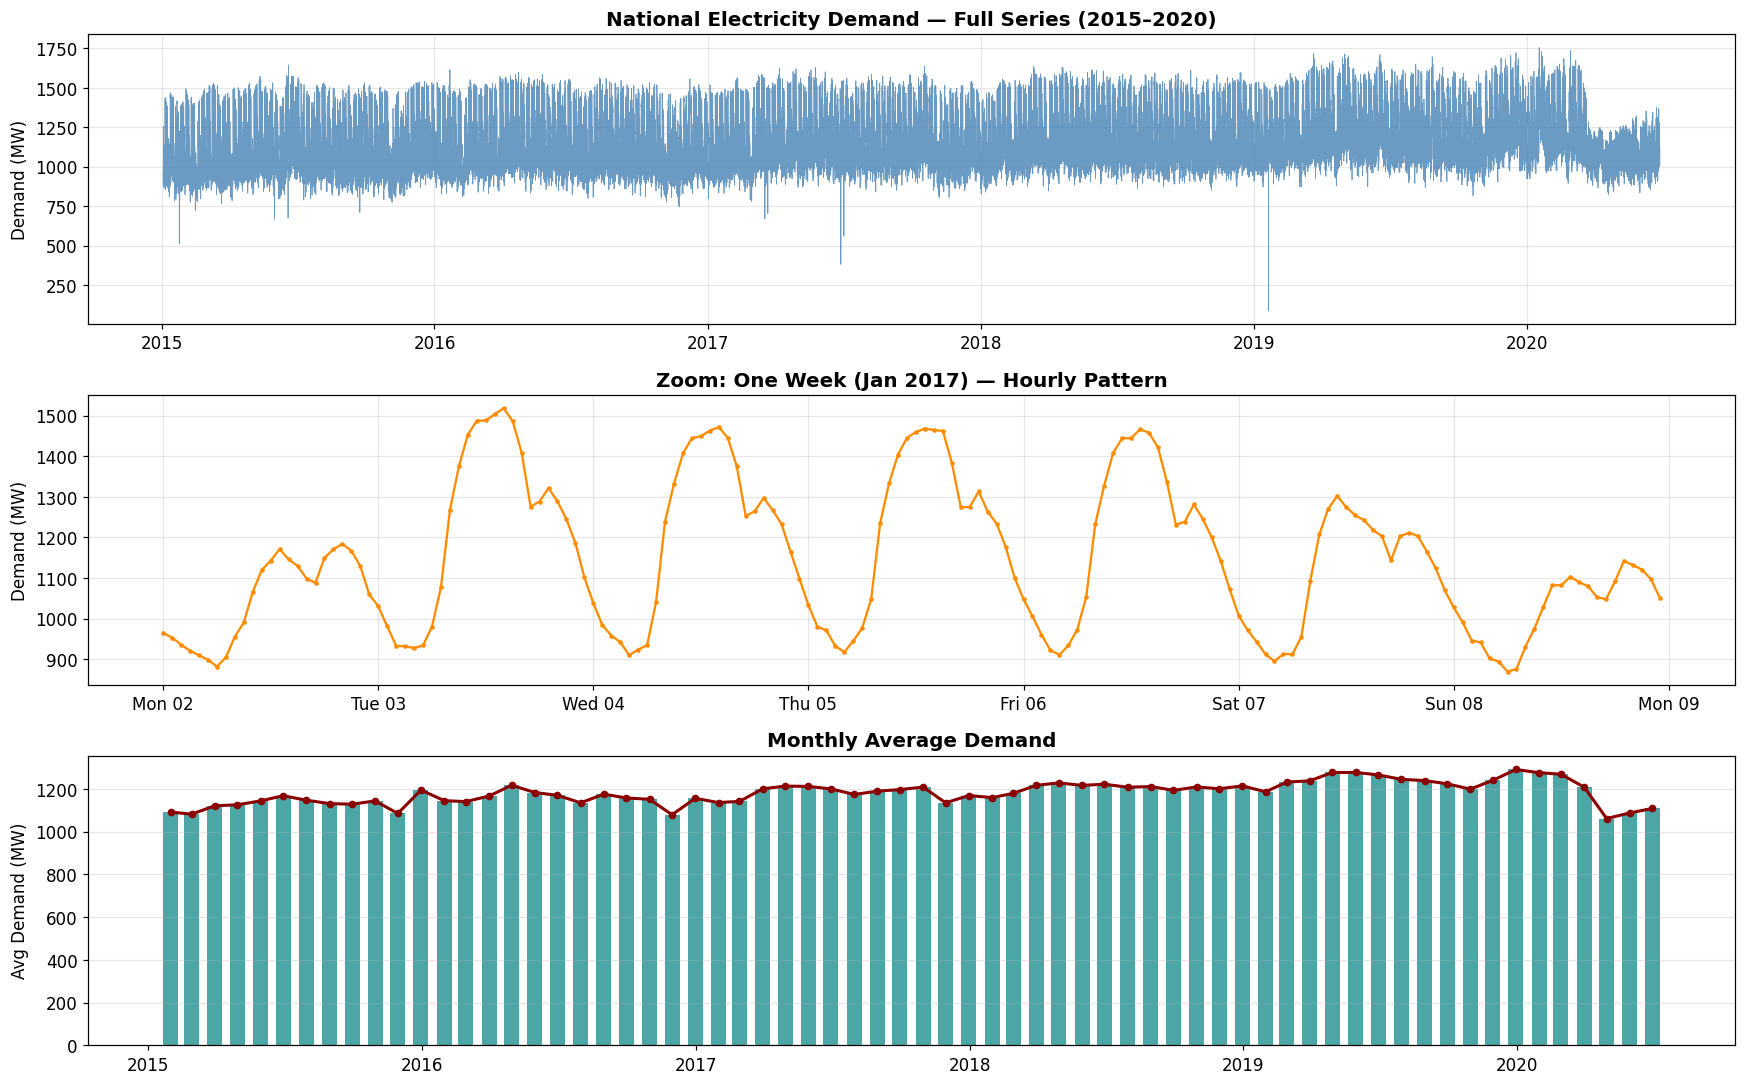

In [7]:
# ── 1b. Full time-series overview ────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

axes[0].plot(df['datetime'], df['nat_demand'], linewidth=0.5, color='steelblue', alpha=0.8)
axes[0].set_title('National Electricity Demand — Full Series (2015–2020)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Demand (MW)')
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].grid(True, alpha=0.3)

sample_week = df[(df['datetime'] >= '2017-01-02') & (df['datetime'] < '2017-01-09')]
axes[1].plot(sample_week['datetime'], sample_week['nat_demand'],
             linewidth=1.5, color='darkorange', marker='o', markersize=2)
axes[1].set_title('Zoom: One Week (Jan 2017) — Hourly Pattern', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Demand (MW)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%a %d'))
axes[1].grid(True, alpha=0.3)

df_monthly = df.set_index('datetime')['nat_demand'].resample('ME').mean()
axes[2].bar(df_monthly.index, df_monthly.values, width=20, color='teal', alpha=0.7)
axes[2].plot(df_monthly.index, df_monthly.values, color='darkred', linewidth=2, marker='o', markersize=4)
axes[2].set_title('Monthly Average Demand', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Avg Demand (MW)')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()

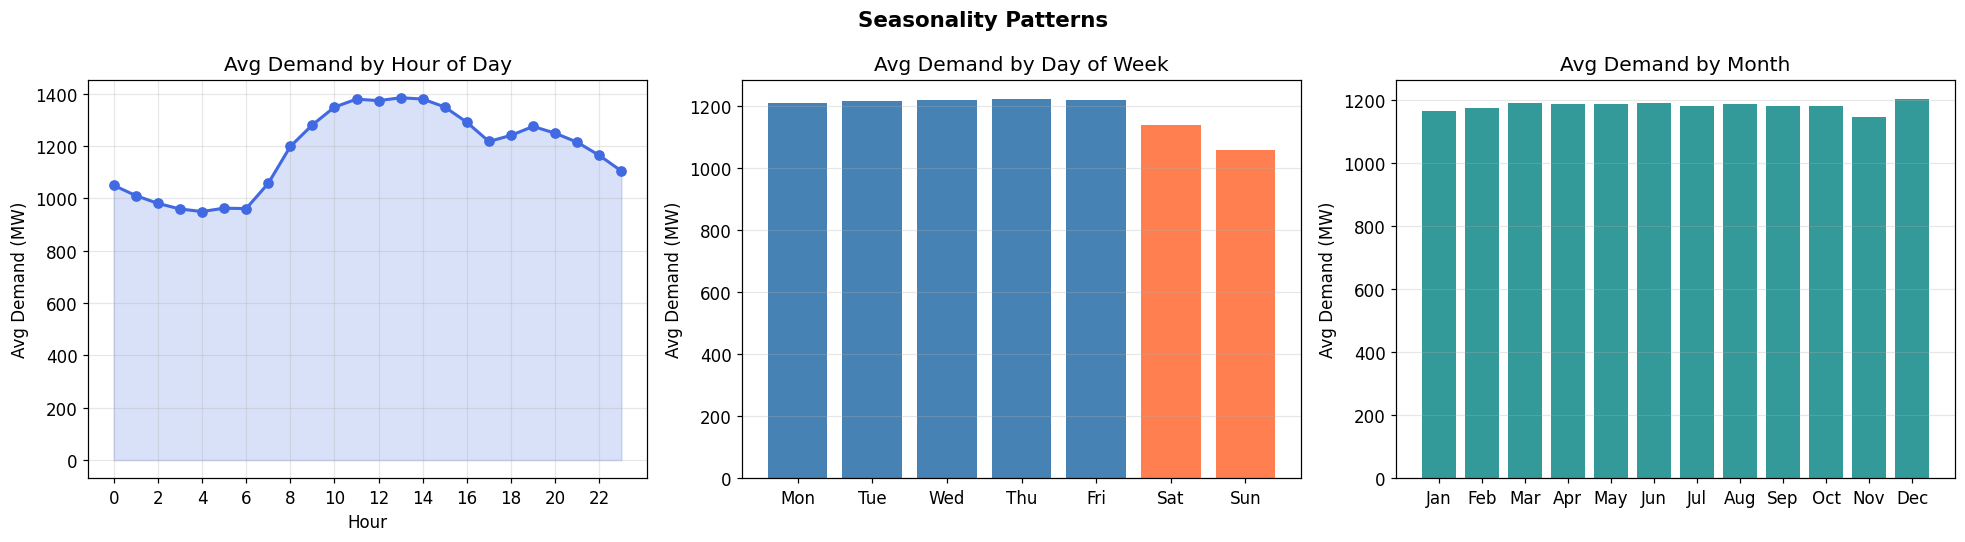

In [8]:
# ── 1c. Seasonality patterns ─────────────────────────────────────────────────
_df = df.copy()
_df['hour']      = _df['datetime'].dt.hour
_df['dayofweek'] = _df['datetime'].dt.dayofweek
_df['month']     = _df['datetime'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hourly = _df.groupby('hour')['nat_demand'].mean()
axes[0].plot(hourly.index, hourly.values, marker='o', linewidth=2, color='royalblue')
axes[0].fill_between(hourly.index, hourly.values, alpha=0.2, color='royalblue')
axes[0].set_title('Avg Demand by Hour of Day')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Avg Demand (MW)')
axes[0].set_xticks(range(0, 24, 2)); axes[0].grid(True, alpha=0.3)

day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily  = _df.groupby('dayofweek')['nat_demand'].mean()
colors = ['steelblue' if d < 5 else 'coral' for d in range(7)]
axes[1].bar(day_names, daily.values, color=colors)
axes[1].set_title('Avg Demand by Day of Week')
axes[1].set_ylabel('Avg Demand (MW)'); axes[1].grid(True, alpha=0.3, axis='y')

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = _df.groupby('month')['nat_demand'].mean()
axes[2].bar(month_names, monthly.values, color='teal', alpha=0.8)
axes[2].set_title('Avg Demand by Month')
axes[2].set_ylabel('Avg Demand (MW)'); axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Seasonality Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_seasonality.png', bbox_inches='tight')
plt.show()

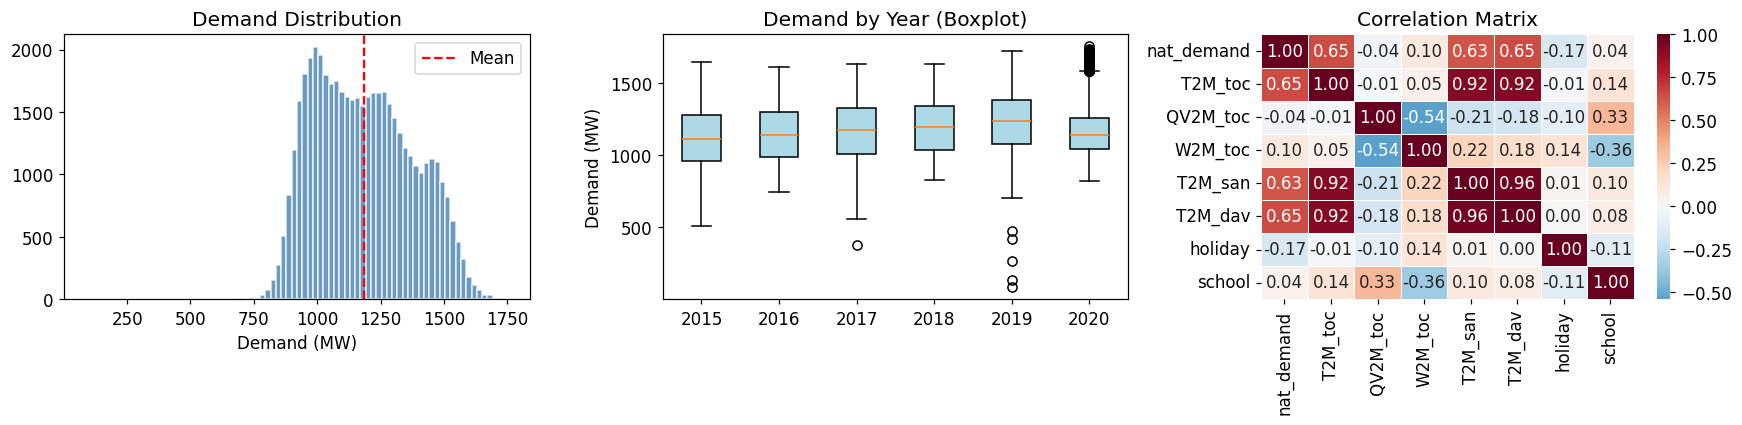

In [9]:
# ── 1d. Distribution & weather correlation ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['nat_demand'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Demand Distribution'); axes[0].set_xlabel('Demand (MW)')
axes[0].axvline(df['nat_demand'].mean(), color='red', linestyle='--', label='Mean')
axes[0].legend()

years = sorted(df['datetime'].dt.year.unique())
axes[1].boxplot([df[df['datetime'].dt.year == y]['nat_demand'].values for y in years],
    labels=years, patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Demand by Year (Boxplot)'); axes[1].set_ylabel('Demand (MW)')

weather_cols = ['nat_demand','T2M_toc','QV2M_toc','W2M_toc','T2M_san','T2M_dav','holiday','school']
corr = df[weather_cols].corr()
sns.heatmap(corr, ax=axes[2], cmap='RdBu_r', center=0, annot=True, fmt='.2f', linewidths=0.5)
axes[2].set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig('eda_distribution.png', bbox_inches='tight')
plt.show()

In [10]:
# ── 1e. Stationarity — ADF Test ──────────────────────────────────────────────
series = df['nat_demand'].dropna()
adf = adfuller(series, autolag='AIC')
print('=== Augmented Dickey-Fuller Test ===')
print(f'ADF Statistic : {adf[0]:.4f}')
print(f'p-value       : {adf[1]:.6f}')
print(f'Critical 1%   : {adf[4]["1%"]:.4f}')
print(f'Critical 5%   : {adf[4]["5%"]:.4f}')
print('Result        :', '✅ Stationary' if adf[1] < 0.05 else '❌ Non-stationary → d=1 needed')

# Also test on first difference
series_diff = series.diff().dropna()
adf2 = adfuller(series_diff, autolag='AIC')
print(f'\nAfter 1st differencing → p-value: {adf2[1]:.6f}',
      '✅ Stationary' if adf2[1] < 0.05 else '❌ Still non-stationary')

=== Augmented Dickey-Fuller Test ===
ADF Statistic : -20.9618
p-value       : 0.000000
Critical 1%   : -3.4305
Critical 5%   : -2.8616
Result        : ✅ Stationary

After 1st differencing → p-value: 0.000000 ✅ Stationary


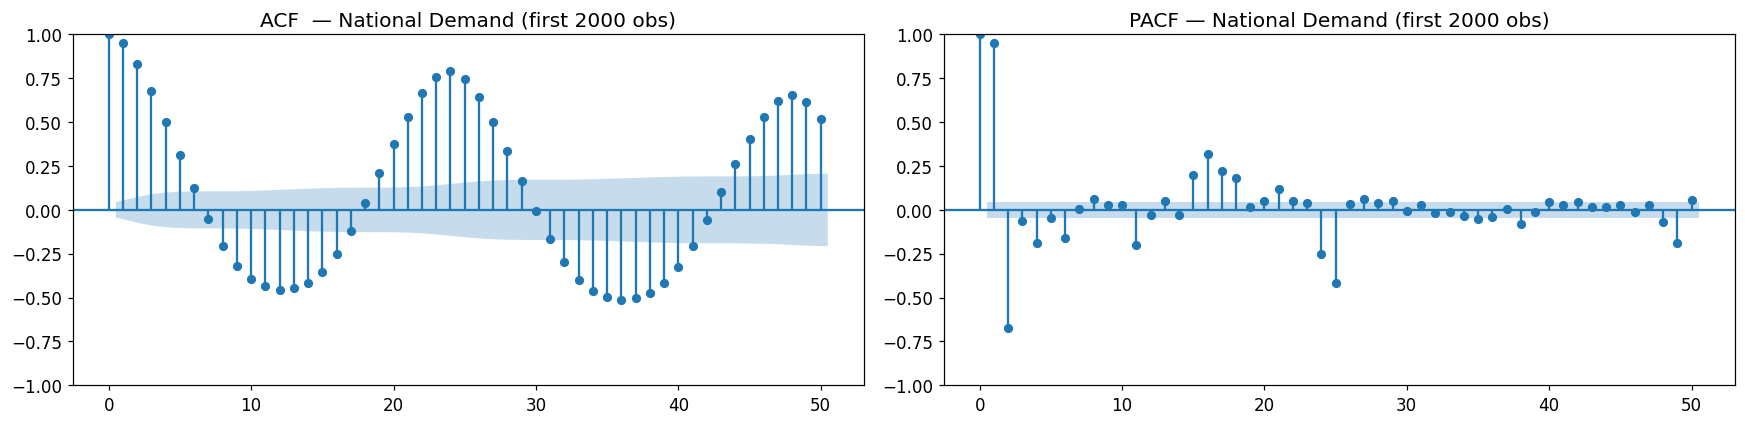


📌 ACF/PACF Interpretation:
  ACF:
    • Slow decay from lag 1        → non-stationary / strong persistence  ⟹  d = 1
    • Sinusoidal bumps at lag 24, 48 → strong DAILY seasonality           ⟹  s = 24, D = 1
  PACF:
    • Large spike at lag 1         → AR(1) component                      ⟹  p ≥ 1
    • Negative spike at lag 2      → possible AR(2)                       ⟹  p ≤ 2
    • Seasonal spike at lag ~24    → seasonal AR component                ⟹  P = 1
  ➜ Baseline: SARIMA(1,1,1)(1,1,1,24)
  ➜ Candidates: (2,1,1), (1,1,2), (3,1,2) — tested in grid search



In [11]:
# ── 1f. ACF / PACF ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf (series[:2000], lags=50, ax=axes[0], title='ACF  — National Demand (first 2000 obs)')
plot_pacf(series[:2000], lags=50, ax=axes[1], title='PACF — National Demand (first 2000 obs)')
plt.tight_layout()
plt.savefig('eda_acf_pacf.png', bbox_inches='tight')
plt.show()

print("""
📌 ACF/PACF Interpretation:
  ACF:
    • Slow decay from lag 1        → non-stationary / strong persistence  ⟹  d = 1
    • Sinusoidal bumps at lag 24, 48 → strong DAILY seasonality           ⟹  s = 24, D = 1
  PACF:
    • Large spike at lag 1         → AR(1) component                      ⟹  p ≥ 1
    • Negative spike at lag 2      → possible AR(2)                       ⟹  p ≤ 2
    • Seasonal spike at lag ~24    → seasonal AR component                ⟹  P = 1
  ➜ Baseline: SARIMA(1,1,1)(1,1,1,24)
  ➜ Candidates: (2,1,1), (1,1,2), (3,1,2) — tested in grid search
""")

## Step 2: Data Preprocessing

In [12]:
df_clean = df.copy()

# Re-index to full hourly grid; interpolate short gaps (≤3 h)
expected_hours = pd.date_range(df_clean['datetime'].min(), df_clean['datetime'].max(), freq='h')
missing_hours  = expected_hours.difference(df_clean['datetime'])
print(f'Missing hourly timestamps: {len(missing_hours)}')

df_clean = df_clean.set_index('datetime').reindex(expected_hours)
df_clean = df_clean.interpolate(method='time', limit=3)
df_clean = df_clean.reset_index().rename(columns={'index': 'datetime'})
df_clean = df_clean.dropna(subset=['nat_demand'])

print(f'Final shape    : {df_clean.shape}')
print(f'Remaining NaNs : {df_clean.isnull().sum().sum()}')

Missing hourly timestamps: 0
Final shape    : (48048, 17)
Remaining NaNs : 0


## Step 3: Feature Engineering

| Feature group | Features | Used by |
|---|---|---|
| Temporal | hour, dow, month, year, quarter, is_weekend, is_business_hour | RF / SHAP |
| Cyclical encoding | hour_sin/cos, dow_sin/cos, month_sin/cos | RF / SHAP |
| Lag features | lag 1,2,3,6,**12**,**24**h, 48h, 168h — aligns with 12h & 24h horizons | RF / SHAP |
| Rolling stats | mean/std over 6h, 24h, 168h windows | RF / SHAP |
| Differencing | diff_1h, diff_24h | RF / SHAP |
| Exogenous (SARIMAX) | T2M_toc, QV2M_toc, W2M_toc, holiday, school, is_weekend | SARIMAX |

> Lag 12 and lag 24 are specifically chosen to align with the two forecasting horizons.
> Lag 1–6 capture short-range autocorrelation within the history window.


In [13]:
def engineer_features(df):
    d = df.copy()

    # ── Temporal ─────────────────────────────────────────────────────────────
    d['hour']             = d['datetime'].dt.hour
    d['dayofweek']        = d['datetime'].dt.dayofweek
    d['month']            = d['datetime'].dt.month
    d['year']             = d['datetime'].dt.year
    d['dayofyear']        = d['datetime'].dt.dayofyear
    d['quarter']          = d['datetime'].dt.quarter
    d['is_weekend']       = (d['dayofweek'] >= 5).astype(int)
    d['is_business_hour'] = d['hour'].between(8, 18).astype(int)

    # ── Cyclical encoding ─────────────────────────────────────────────────────
    d['hour_sin']  = np.sin(2 * np.pi * d['hour']      / 24)
    d['hour_cos']  = np.cos(2 * np.pi * d['hour']      / 24)
    d['dow_sin']   = np.sin(2 * np.pi * d['dayofweek'] / 7)
    d['dow_cos']   = np.cos(2 * np.pi * d['dayofweek'] / 7)
    d['month_sin'] = np.sin(2 * np.pi * d['month']     / 12)
    d['month_cos'] = np.cos(2 * np.pi * d['month']     / 12)

    # ── Lag features (covers 12h & 24h horizons + daily/weekly memory) ───────
    for lag in [1, 2, 3, 4, 6, 12, 24, 48, 168]: # Added 4 to the list of lags
        d[f'demand_lag_{lag}h'] = d['nat_demand'].shift(lag)

    # ── Rolling statistics ────────────────────────────────────────────────────
    for w in [6, 12, 24, 168]:
        d[f'demand_roll_mean_{w}h'] = d['nat_demand'].shift(1).rolling(w).mean()
        d[f'demand_roll_std_{w}h']  = d['nat_demand'].shift(1).rolling(w).std()

    # ── Differencing ──────────────────────────────────────────────────────────
    d['demand_diff_1h']  = d['nat_demand'].diff(1)
    d['demand_diff_24h'] = d['nat_demand'].diff(24)

    return d

df_feat = engineer_features(df_clean)
print(f'Features added : {df_feat.shape[1] - df_clean.shape[1]}')
print(f'Total columns  : {df_feat.shape[1]}')
df_feat.head(3)

Features added : 33
Total columns  : 50


,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,...,demand_roll_mean_6h,demand_roll_std_6h,demand_roll_mean_12h,demand_roll_std_12h,demand_roll_mean_24h,demand_roll_std_24h,demand_roll_mean_168h,demand_roll_std_168h,demand_diff_1h,demand_diff_24h
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-58.1695,NaN
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-11.9067,NaN


## Step 4: 4-Fold Year-Based Expanding Window CV + Held-out Test Set

```
CV1 : Train 2015            → Validate 2016
CV2 : Train 2015–2016       → Validate 2017
CV3 : Train 2015–2017       → Validate 2018
CV4 : Train 2015–2018       → Validate 2019
─────────────────────────────────────────────────
TEST: Train 2015–2019       → Test 2020 (Jan–Feb)  ← HELD-OUT
```

> **Why year-based?** Calendar boundaries are the most defensible split for energy data:
> seasonal patterns repeat yearly, and year-level splits prevent future-year data from
> leaking into training — a risk with sample-count splits.
>
> **Walk-forward validation:** each fold's training set strictly precedes its validation set
> (no shuffling), preserving the temporal causal order required for time-series evaluation.
>
> **Held-out test separation:** 2020 Jan–Feb is a completely separate partition — it is never
> used during model selection, grid search, or cross-fold evaluation. Only the **final locked-in
> model** is scored on TEST, giving an unbiased estimate of real-world performance.


CV1  Train 2015–2015 ( 8543 hrs)  | Val 2016 (8784 hrs)
CV2  Train 2015–2016 (17327 hrs)  | Val 2017 (8760 hrs)
CV3  Train 2015–2017 (26087 hrs)  | Val 2018 (8760 hrs)
CV4  Train 2015–2018 (34847 hrs)  | Val 2019 (8760 hrs)
TEST  Train 2015–2019 (43607 hrs)  | Test 2020 Jan–Feb (4273 hrs)


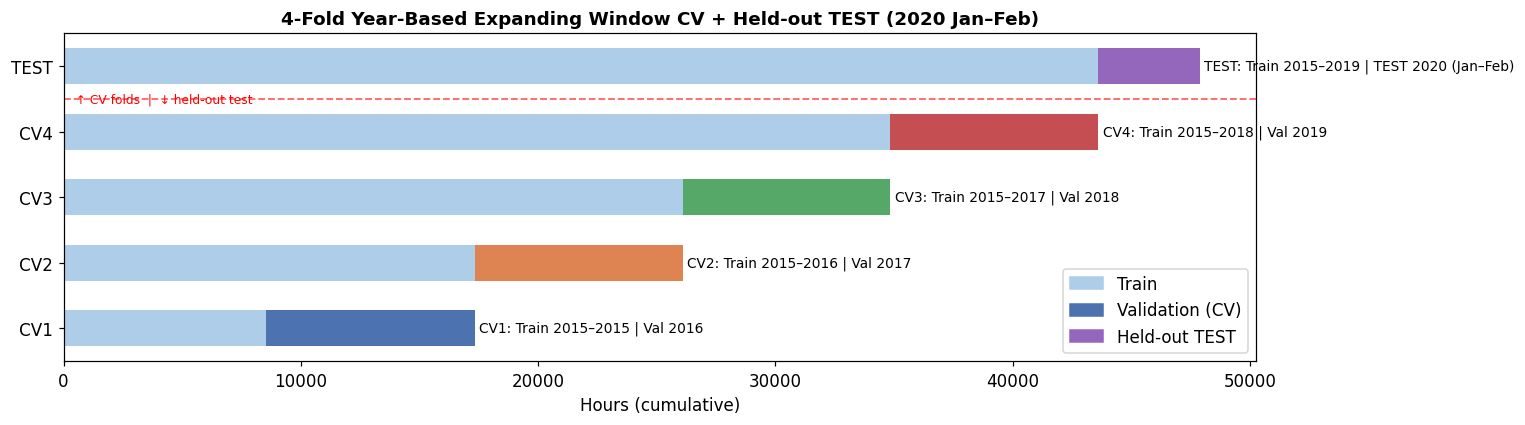

In [14]:
df_model = df_feat.dropna().reset_index(drop=True)

# ── 4 CV folds (for model selection) ─────────────────────────────────────────
TRAIN_YEARS = [
    [2015],
    [2015, 2016],
    [2015, 2016, 2017],
    [2015, 2016, 2017, 2018],
]
VAL_YEARS = [2016, 2017, 2018, 2019]

# ── Held-out TEST set (never used in CV) ─────────────────────────────────────
TEST_TRAIN_YEARS = [2015, 2016, 2017, 2018, 2019]
TEST_YEAR        = 2020   # Jan–Feb only (dataset ends Feb 2020)

def make_year_cv_splits(df, train_years_list, val_years_list):
    splits = {}
    for i, (train_yrs, val_yr) in enumerate(zip(train_years_list, val_years_list)):
        fold = f'CV{i+1}'
        tr_mask = df['year'].isin(train_yrs)
        va_mask = df['year'] == val_yr
        splits[fold] = {'train': df[tr_mask].copy(), 'val': df[va_mask].copy()}
        print(f"{fold}  Train {train_yrs[0]}–{train_yrs[-1]} ({tr_mask.sum():5d} hrs)  "
              f"| Val {val_yr} ({va_mask.sum():4d} hrs)")
    return splits

cv_splits = make_year_cv_splits(df_model, TRAIN_YEARS, VAL_YEARS)

# ── Build TEST split separately ──────────────────────────────────────────────
test_tr_mask = df_model['year'].isin(TEST_TRAIN_YEARS)
test_va_mask = df_model['year'] == TEST_YEAR
test_split = {
    'train': df_model[test_tr_mask].copy(),
    'val':   df_model[test_va_mask].copy(),   # 'val' key for code compatibility
}
print(f"TEST  Train {TEST_TRAIN_YEARS[0]}–{TEST_TRAIN_YEARS[-1]} "
      f"({test_tr_mask.sum():5d} hrs)  | Test {TEST_YEAR} Jan–Feb ({test_va_mask.sum():4d} hrs)")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
colors_cv = ['#4C72B0','#DD8452','#55A868','#C44E52']
all_rows = list(cv_splits.items()) + [('TEST', test_split)]
for i, (name, sp) in enumerate(all_rows):
    n_tr, n_va = len(sp['train']), len(sp['val'])
    ax.barh(i, n_tr, left=0,    color='#AECDE8', height=0.55)
    colour = colors_cv[i] if i < 4 else '#9467bd'
    ax.barh(i, n_va, left=n_tr, color=colour, height=0.55)
    if name == 'TEST':
        lbl = f"Train 2015–2019 | TEST 2020 (Jan–Feb)"
    else:
        lbl = f"Train {TRAIN_YEARS[i][0]}–{TRAIN_YEARS[i][-1]} | Val {VAL_YEARS[i]}"
    ax.text(n_tr + n_va + 200, i, f'{name}: {lbl}', va='center', fontsize=9)

ax.set_yticks(range(len(all_rows)))
ax.set_yticklabels([n for n,_ in all_rows])
ax.set_xlabel('Hours (cumulative)')
ax.set_title('4-Fold Year-Based Expanding Window CV + Held-out TEST (2020 Jan–Feb)',
             fontsize=12, fontweight='bold')
ax.axhline(3.5, color='red', linestyle='--', linewidth=1.2, alpha=0.6)
ax.text(200, 3.5, '  ↑ CV folds  |  ↓ held-out test', color='red',
        fontsize=8, va='center')
legend_handles = [
    Patch(color='#AECDE8', label='Train'),
    Patch(color=colors_cv[0], label='Validation (CV)'),
    Patch(color='#9467bd', label='Held-out TEST'),
]
ax.legend(handles=legend_handles, loc='lower right')
plt.tight_layout()
plt.savefig('cv_splits_year.png', bbox_inches='tight')
plt.show()


## Step 5: Model Justification — Persistence → ARIMA → SARIMA → SARIMAX

Choosing a **baseline → trend → seasonality → exogenous** hierarchy allows a structured ablation:
each model adds one capability over the previous, and every trained model must beat the naïve baselines
to justify its complexity.

| Model | Description | Why included |
|---|---|---|
| **Persistence (naïve)** | ŷ(t+h) = y(t) — carry forward the last observed value | **Required baseline.** Absolute lower bar; any useful model must beat this. |
| **Seasonal naïve** | ŷ(t+h) = y(t+h−24) — "same hour yesterday" | Strong baseline that already captures the 24 h daily cycle without any fitting. |
| **ARIMA(p,d,q)** | AutoRegressive Integrated Moving Average — trend + autocorrelation only | Classical baseline with no seasonality. Quantifies the cost of ignoring the daily cycle (s=24). |
| **SARIMA(p,d,q)(P,D,Q,s)** | ARIMA + seasonal terms at period s=24 | Directly addresses the dominant daily pattern confirmed by ACF. Expected to clearly outperform ARIMA. |
| **SARIMAX** | SARIMA + exogenous regressors | Adds weather (T2M, QV2M, W2M) and calendar (holiday, school, weekend) drivers visible in the correlation matrix. Tests whether external information reduces residual error beyond seasonal structure alone. |

> **Justification summary:** The five models form a natural hierarchy — *naïve → naïve+seasonality → trend → trend+seasonality → trend+seasonality+drivers*.
> Comparing them isolates the contribution of each component and satisfies the methodology requirement
> to justify model choice and include appropriate baselines rather than only implement complex models.

### SARIMA configurations tested (ACF/PACF-derived + literature, Table 3 reference)
The grid includes configurations that appear in published short-term load forecasting benchmarks:

```
(3,1,2)(1,0,1,7)   (1,0,2)(1,0,1,7)   (1,1,2)(1,0,2,7)   (3,1,2)(2,0,1,7)
(1,1,1)(1,1,1,24)  (2,1,1)(1,1,1,24)  (1,1,2)(1,1,1,24)
```

The s=7 variants test weekly seasonality; the s=24 variants test daily seasonality (expected to dominate
based on ACF analysis).


## Step 6: Hyperparameter Grid Search — SARIMA

**Workflow:**
```
CV Training (CV1–CV4) → measure AIC + CV1 RMSE → select best order
       ↑                                                  │
       └──────────────── re-train with best order ◄───────┘
```

Grid is evaluated on **CV1 only** for speed. Best model (lowest AIC) is then locked in
and re-trained across **all 5 folds** in Step 7.

> ⏳ ~15–25 min on Colab CPU. Reduce `MAX_TRAIN_HOURS` to 500 for a quick test.


In [15]:
# ── Metric helpers ───────────────────────────────────────────────────────────
def rmse(y_true, y_pred): return np.sqrt(mean_squared_error(y_true, y_pred))
def mae (y_true, y_pred): return mean_absolute_error(y_true, y_pred)
def mape(y_true, y_pred): return np.mean(np.abs((np.array(y_true)-np.array(y_pred))/np.array(y_true)))*100

def evaluate(y_true, y_pred, label=''):
    r, m, p = rmse(y_true,y_pred), mae(y_true,y_pred), mape(y_true,y_pred)
    print(f"{label:65s}  RMSE={r:.2f}  MAE={m:.2f}  MAPE={p:.2f}%")
    return {'RMSE': r, 'MAE': m, 'MAPE': p}

print('✅ Metrics defined')

✅ Metrics defined


In [16]:
# ── Candidate configurations ─────────────────────────────────────────────────
# Format: (p, d, q, P, D, Q, s, label)
# Includes: ACF/PACF-derived candidates + literature configurations (Table 3)
CANDIDATE_CONFIGS = [
    # ── s=24 (daily, primary) ────────────────────────────────────────────────
    (1, 1, 1,  1, 1, 1, 24, 'SARIMA(1,1,1)(1,1,1,24)'),   # ACF/PACF baseline
    (2, 1, 1,  1, 1, 1, 24, 'SARIMA(2,1,1)(1,1,1,24)'),   # AR(2) variant
    (1, 1, 2,  1, 1, 1, 24, 'SARIMA(1,1,2)(1,1,1,24)'),   # MA(2) variant
    # ── s=7 (weekly, secondary) ──────────────────────────────────────────────
    (3, 1, 2,  1, 0, 1,  7, 'SARIMA(3,1,2)(1,0,1,7)'),
    (1, 0, 2,  1, 0, 1,  7, 'SARIMA(1,0,2)(1,0,1,7)'),
    (1, 1, 2,  1, 0, 2,  7, 'SARIMA(1,1,2)(1,0,2,7)'),
    (3, 1, 2,  2, 0, 1,  7, 'SARIMA(3,1,2)(2,0,1,7)'),
]

MAX_TRAIN_HOURS = 1000   # ← raise to 2000 for better accuracy
cv1_train_s = cv_splits['CV1']['train']['nat_demand'].values[-MAX_TRAIN_HOURS:]
cv1_val_s   = cv_splits['CV1']['val']['nat_demand'].values[:200]

print(f'Candidates    : {len(CANDIDATE_CONFIGS)}')
print(f'Train window  : {len(cv1_train_s)} hrs | Quick-val: {len(cv1_val_s)} hrs')

Candidates    : 7
Train window  : 1000 hrs | Quick-val: 200 hrs


In [17]:
grid_results = []

for cfg in CANDIDATE_CONFIGS:
    p, d, q, sp, sd, sq, s, label = cfg
    try:
        m  = SARIMAX(cv1_train_s, order=(p,d,q), seasonal_order=(sp,sd,sq,s),
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        fc = m.forecast(len(cv1_val_s))
        r  = rmse(cv1_val_s, fc)
        grid_results.append({'Model':label,'p':p,'d':d,'q':q,'P':sp,'D':sd,'Q':sq,'s':s,
                             'AIC':m.aic,'BIC':m.bic,'CV1_RMSE':r})
        print(f'  ✅ {label:42s}  AIC={m.aic:.1f}  BIC={m.bic:.1f}  RMSE={r:.2f}')
    except Exception as e:
        print(f'  ❌ {label}: {e}')

grid_df = pd.DataFrame(grid_results).sort_values('CV1_RMSE').reset_index(drop=True)
print('\n=== Grid Search Results (sorted by CV1_RMSE) ===')
display(grid_df[['Model','AIC','BIC','CV1_RMSE']])

  ✅ SARIMA(1,1,1)(1,1,1,24)                     AIC=8589.7  BIC=8614.0  RMSE=156.02
  ✅ SARIMA(2,1,1)(1,1,1,24)                     AIC=8588.0  BIC=8617.1  RMSE=155.41
  ✅ SARIMA(1,1,2)(1,1,1,24)                     AIC=8578.8  BIC=8607.9  RMSE=154.95


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ✅ SARIMA(3,1,2)(1,0,1,7)                      AIC=10187.3  BIC=10226.5  RMSE=194.05
  ✅ SARIMA(1,0,2)(1,0,1,7)                      AIC=10364.7  BIC=10394.1  RMSE=318.40
  ✅ SARIMA(1,1,2)(1,0,2,7)                      AIC=10239.2  BIC=10273.5  RMSE=192.37
  ✅ SARIMA(3,1,2)(2,0,1,7)                      AIC=10130.6  BIC=10174.6  RMSE=193.93

=== Grid Search Results (sorted by CV1_RMSE) ===


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Model,AIC,BIC,CV1_RMSE
0,"SARIMA(1,1,2)(1,1,1,24)",8578.820066,8607.946193,154.947407
1,"SARIMA(2,1,1)(1,1,1,24)",8587.961096,8617.093549,155.410605
2,"SARIMA(1,1,1)(1,1,1,24)",8589.675889,8613.952933,156.024409
3,"SARIMA(1,1,2)(1,0,2,7)",10239.240053,10273.467192,192.365896
4,"SARIMA(3,1,2)(2,0,1,7)",10130.621323,10174.627644,193.927675
5,"SARIMA(3,1,2)(1,0,1,7)",10187.293450,10226.467004,194.045779
6,"SARIMA(1,0,2)(1,0,1,7)",10364.684135,10394.070364,318.403635


🏆 Best SARIMA : SARIMA(1,1,2)(1,1,1,24)
   AIC=8578.8  BIC=8607.9  CV1_RMSE=154.95


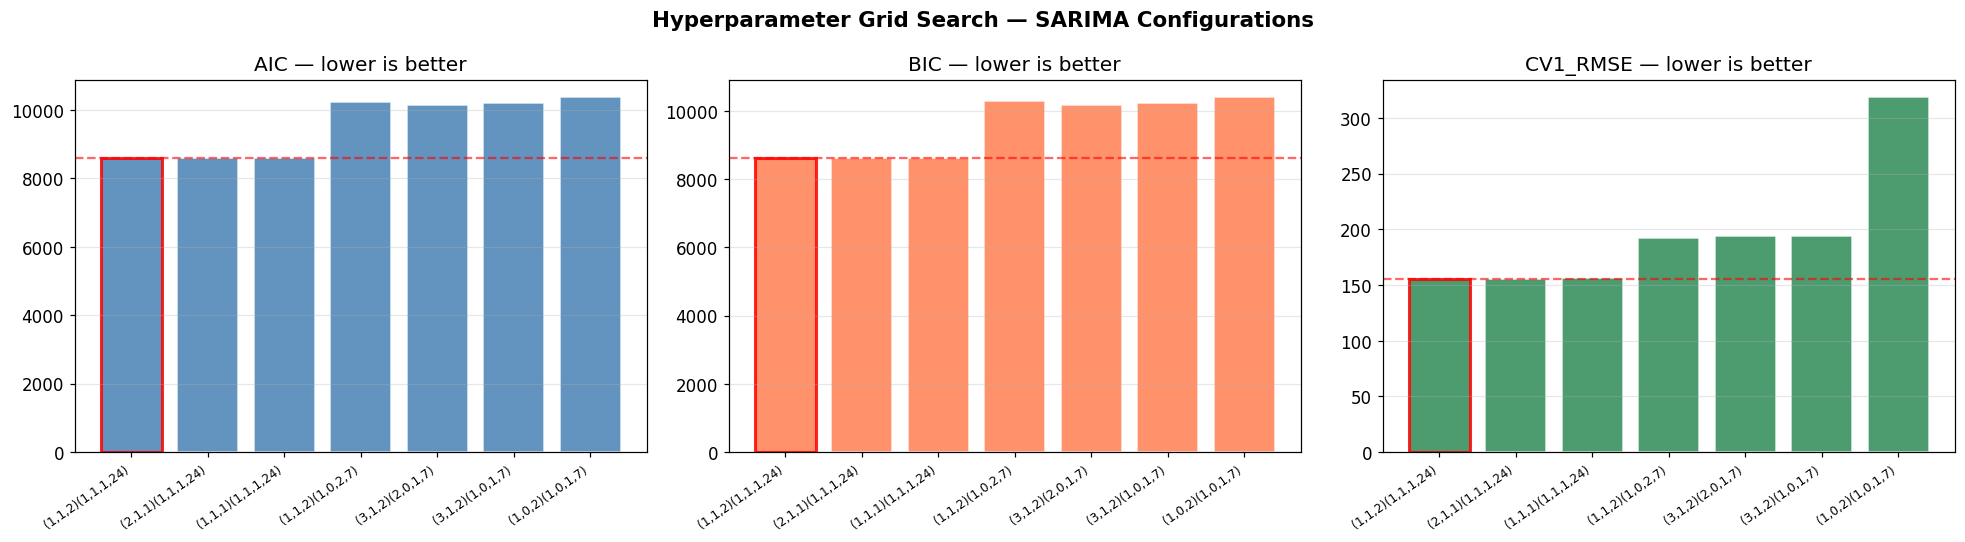

In [18]:
# ── Select best SARIMA order ──────────────────────────────────────────────────
best         = grid_df.iloc[0]
best_p       = int(best.p);  best_d  = int(best.d);  best_q  = int(best.q)
best_sp      = int(best.P);  best_sd = int(best.D);  best_sq = int(best.Q)
best_s       = int(best.s)
best_label   = best.Model

print(f'🏆 Best SARIMA : {best_label}')
print(f'   AIC={best.AIC:.1f}  BIC={best.BIC:.1f}  CV1_RMSE={best.CV1_RMSE:.2f}')

# ── Bar chart: AIC / BIC / RMSE ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
short_labels = [r.Model.replace('SARIMA','') for _, r in grid_df.iterrows()]

for ax, metric, color in zip(axes, ['AIC','BIC','CV1_RMSE'], ['steelblue','coral','seagreen']):
    bars = ax.bar(range(len(grid_df)), grid_df[metric], color=color, alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(grid_df)))
    ax.set_xticklabels(short_labels, rotation=35, ha='right', fontsize=8)
    ax.set_title(f'{metric} — lower is better')
    ax.axhline(grid_df[metric].min(), color='red', linestyle='--', alpha=0.6)
    # highlight best
    bars[0].set_edgecolor('red'); bars[0].set_linewidth(2)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Hyperparameter Grid Search — SARIMA Configurations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grid_search.png', bbox_inches='tight')
plt.show()

## Step 7: Model Training — Baselines + ARIMA / SARIMA / SARIMAX Across All 4 CV Folds

Five forecasters produced per fold (two baselines + three statistical models):

| Model | Type | Order | Notes |
|---|---|---|---|
| **Persistence** | Baseline (naïve) | — | ŷ(t+h) = y(t): carry last value forward |
| **Seasonal naïve** | Baseline (naïve) | — | ŷ(t+h) = y(t+h−24): "same hour yesterday" |
| **ARIMA** | Statistical | (2,1,2) | No seasonal terms — ablation baseline |
| **SARIMA** | Statistical | Best from grid | Seasonal structure, no exogenous |
| **SARIMAX** | Statistical | Best SARIMA + exog | Weather + calendar features |

Exogenous: `T2M_toc`, `QV2M_toc`, `W2M_toc`, `holiday`, `school`, `is_weekend`

> **Important:** Only CV1–CV4 are used here. The **2020 TEST set is never touched** during
> training or model selection — it's reserved for the final Step 8/9 evaluation of the locked-in model.
>
> ⏳ ~35–70 min full 4-fold run on Colab CPU. Control `MAX_TRAIN_HRS` and `MAX_VAL_HRS`.


In [19]:
EXOG_COLS     = ['T2M_toc', 'QV2M_toc', 'W2M_toc', 'holiday', 'school', 'is_weekend']
MAX_TRAIN_HRS = 2000   # hours of training data used per fold (raise for accuracy)
MAX_VAL_HRS   = 500    # hours from validation set to forecast

# ── Convergence settings ─────────────────────────────────────────────────────
# TEST val = Jan-Feb 2020 (COVID period, anomalous demand patterns).
# Increase max_iter and use method='powell' as fallback to reduce ConvergenceWarnings.
FIT_KWARGS = dict(
    disp=False,
    maxiter=200,
    method='lbfgs',
    optim_score=None,
)

def safe_fit(model, fold_name='', label=''):
    """Try lbfgs first; fall back to powell if it fails to converge."""
    import warnings
    try:
        res = model.fit(**FIT_KWARGS)
        return res
    except Exception:
        pass
    try:
        res = model.fit(disp=False, maxiter=300, method='powell')
        return res
    except Exception as e:
        print(f'  ⚠️  {fold_name} {label} both optimisers failed: {e}')
        return None


# ── Baseline forecasters (no fitting required) ───────────────────────────────
def persistence_forecast(train_series, n_val):
    """ŷ(t+h) = last observed training value — for every step in val horizon."""
    last = train_series[-1]
    return np.repeat(last, n_val)

def seasonal_naive_forecast(train_series, val_series_length, period=24):
    """ŷ(t+h) = y(t+h - period): 'same hour yesterday' carried through val window."""
    n = val_series_length
    cycle = np.asarray(train_series[-period:])
    reps = int(np.ceil(n / period))
    return np.tile(cycle, reps)[:n]


def train_and_forecast_one_split(split, fold_name, best_p, best_d, best_q,
                                  best_sp, best_sd, best_sq, best_s, best_label):
    """Trains all 5 forecasters on `split['train']` and forecasts on `split['val']`.
    Returns (fold_rows_for_metrics, fc_dict, tr_dict, train_series)."""
    tr_s  = split['train']['nat_demand'].values[-MAX_TRAIN_HRS:]
    va_s  = split['val']['nat_demand'].values[:MAX_VAL_HRS]
    tr_ex = split['train'][EXOG_COLS].values[-MAX_TRAIN_HRS:]
    va_ex = split['val'][EXOG_COLS].values[:MAX_VAL_HRS]

    fold_fc = {'actual': va_s}
    fold_tr = {}
    rows = []

    # ── Persistence ──────────────────────────────────────────────────────────
    try:
        fc_pers = persistence_forecast(tr_s, len(va_s))
        fold_fc['Persistence'] = fc_pers
        fold_tr['Persistence'] = np.concatenate([[tr_s[0]], tr_s[:-1]])
        m = evaluate(va_s, fc_pers, f'  {fold_name} Persistence')
        rows.append({'Fold':fold_name,'Model':'Persistence', **m})
    except Exception as e:
        print(f'  ⚠️  Persistence failed: {e}')

    # ── Seasonal naïve (24h) ─────────────────────────────────────────────────
    try:
        fc_snaive = seasonal_naive_forecast(tr_s, len(va_s), period=24)
        fold_fc['SeasonalNaive'] = fc_snaive
        fold_tr['SeasonalNaive'] = np.concatenate([np.full(24, tr_s[0]), tr_s[:-24]])
        m = evaluate(va_s, fc_snaive, f'  {fold_name} SeasonalNaive')
        rows.append({'Fold':fold_name,'Model':'SeasonalNaive', **m})
    except Exception as e:
        print(f'  ⚠️  SeasonalNaive failed: {e}')

    # ── ARIMA(2,1,2) — no seasonality ────────────────────────────────────────
    try:
        model_a = SARIMAX(tr_s, order=(2,1,2),
                          enforce_stationarity=False, enforce_invertibility=False)
        res_a = safe_fit(model_a, fold_name, 'ARIMA')
        if res_a is not None:
            fc_a = res_a.forecast(len(va_s))
            fold_fc['ARIMA'] = np.asarray(fc_a)
            fold_tr['ARIMA'] = np.asarray(res_a.fittedvalues)
            m = evaluate(va_s, fc_a, f'  {fold_name} ARIMA(2,1,2)')
            rows.append({'Fold':fold_name,'Model':'ARIMA', **m})
    except Exception as e:
        print(f'  ⚠️  ARIMA failed: {e}')

    # ── SARIMA ──────────────────────────────────────────────────────────────
    try:
        model_s = SARIMAX(tr_s, order=(best_p,best_d,best_q),
                          seasonal_order=(best_sp,best_sd,best_sq,best_s),
                          enforce_stationarity=False, enforce_invertibility=False)
        res_s = safe_fit(model_s, fold_name, 'SARIMA')
        if res_s is not None:
            fc_s = res_s.forecast(len(va_s))
            fold_fc['SARIMA'] = np.asarray(fc_s)
            fold_tr['SARIMA'] = np.asarray(res_s.fittedvalues)
            m = evaluate(va_s, fc_s, f'  {fold_name} {best_label}')
            rows.append({'Fold':fold_name,'Model':'SARIMA', **m})
    except Exception as e:
        print(f'  ⚠️  SARIMA failed: {e}')

    # ── SARIMAX ─────────────────────────────────────────────────────────────
    try:
        model_x = SARIMAX(tr_s, exog=tr_ex,
                          order=(best_p,best_d,best_q),
                          seasonal_order=(best_sp,best_sd,best_sq,best_s),
                          enforce_stationarity=False, enforce_invertibility=False)
        res_x = safe_fit(model_x, fold_name, 'SARIMAX')
        if res_x is not None:
            fc_x = res_x.forecast(len(va_s), exog=va_ex)
            fold_fc['SARIMAX'] = np.asarray(fc_x)
            fold_tr['SARIMAX'] = np.asarray(res_x.fittedvalues)
            m = evaluate(va_s, fc_x, f'  {fold_name} SARIMAX + exog')
            rows.append({'Fold':fold_name,'Model':'SARIMAX', **m})
    except Exception as e:
        print(f'  ⚠️  SARIMAX failed: {e}')

    return rows, fold_fc, fold_tr, tr_s


# ─────────────────────────────────────────────────────────────────────────────
# Run across 4 CV folds
# ─────────────────────────────────────────────────────────────────────────────
all_results = []
stored      = {}   # per-fold forecast store for CV analysis

for fold_name, sp in cv_splits.items():
    i = list(cv_splits.keys()).index(fold_name)
    print(f'\n{"═"*68}')
    print(f'📂 {fold_name}  |  Train {TRAIN_YEARS[i]}  |  Val {VAL_YEARS[i]}')

    rows, fold_fc, fold_tr, tr_s = train_and_forecast_one_split(
        sp, fold_name,
        best_p, best_d, best_q, best_sp, best_sd, best_sq, best_s, best_label,
    )
    all_results.extend(rows)
    stored[fold_name] = {'fc': fold_fc, 'tr': fold_tr, 'train_series': tr_s}

results_df = pd.DataFrame(all_results)
print('\n=== CV Fold Results (CV1–CV4) ===')
display(results_df.round(2))


# ─────────────────────────────────────────────────────────────────────────────
# Train on Train-all (2015-2019) and forecast on HELD-OUT TEST (2020 Jan-Feb)
# ─────────────────────────────────────────────────────────────────────────────
print(f'\n{"═"*68}')
print(f'🔒 HELD-OUT TEST  |  Train 2015–2019  |  Test 2020 (Jan–Feb)')
print("═"*68)

test_rows, test_fc, test_tr, test_train_series = train_and_forecast_one_split(
    test_split, 'TEST',
    best_p, best_d, best_q, best_sp, best_sd, best_sq, best_s, best_label,
)

test_results_df = pd.DataFrame(test_rows)
print('\n=== TEST Results (held-out 2020 Jan–Feb) ===')
display(test_results_df.round(2))

# Convenient aliases used in later cells
test_forecasts = {'fc': test_fc, 'tr': test_tr, 'train_series': test_train_series}



════════════════════════════════════════════════════════════════════
📂 CV1  |  Train [2015]  |  Val 2016
  CV1 Persistence                                                  RMSE=195.42  MAE=167.51  MAPE=14.67%
  CV1 SeasonalNaive                                                RMSE=133.15  MAE=110.92  MAPE=9.93%
  CV1 ARIMA(2,1,2)                                                 RMSE=199.68  MAE=173.58  MAPE=15.87%
  CV1 SARIMA(1,1,2)(1,1,1,24)                                      RMSE=178.34  MAE=145.55  MAPE=13.74%
  CV1 SARIMAX + exog                                               RMSE=187.43  MAE=154.34  MAPE=14.56%

════════════════════════════════════════════════════════════════════
📂 CV2  |  Train [2015, 2016]  |  Val 2017
  CV2 Persistence                                                  RMSE=190.02  MAE=160.74  MAPE=13.94%
  CV2 SeasonalNaive                                                RMSE=124.06  MAE=92.49  MAPE=7.82%
  CV2 ARIMA(2,1,2)                                       

,Fold,Model,RMSE,MAE,MAPE
0,CV1,Persistence,195.42,167.51,14.67
1,CV1,SeasonalNaive,133.15,110.92,9.93
2,CV1,ARIMA,199.68,173.58,15.87
3,CV1,SARIMA,178.34,145.55,13.74
4,CV1,SARIMAX,187.43,154.34,14.56
5,CV2,Persistence,190.02,160.74,13.94
6,CV2,SeasonalNaive,124.06,92.49,7.82
7,CV2,ARIMA,185.83,161.76,14.75
8,CV2,SARIMA,129.49,96.47,9.11
9,CV2,SARIMAX,123.60,90.03,8.46



════════════════════════════════════════════════════════════════════
🔒 HELD-OUT TEST  |  Train 2015–2019  |  Test 2020 (Jan–Feb)
════════════════════════════════════════════════════════════════════
  TEST Persistence                                                 RMSE=271.94  MAE=218.86  MAPE=15.84%
  TEST SeasonalNaive                                               RMSE=170.10  MAE=133.31  MAPE=9.91%
  TEST ARIMA(2,1,2)                                                RMSE=200.10  MAE=166.13  MAPE=13.02%
  TEST SARIMA(1,1,2)(1,1,1,24)                                     RMSE=218.05  MAE=182.32  MAPE=13.84%
  TEST SARIMAX + exog                                              RMSE=204.17  MAE=171.97  MAPE=13.09%

=== TEST Results (held-out 2020 Jan–Feb) ===


,Fold,Model,RMSE,MAE,MAPE
0,TEST,Persistence,271.94,218.86,15.84
1,TEST,SeasonalNaive,170.10,133.31,9.91
2,TEST,ARIMA,200.10,166.13,13.02
3,TEST,SARIMA,218.05,182.32,13.84
4,TEST,SARIMAX,204.17,171.97,13.09


## Step 8: Model Evaluation — Cross-Fold MAE / RMSE / MAPE

=== Average Metrics Across CV1–CV4 ===


RMSE            MAE          MAPE      
                 mean    std    mean    std   mean   std
Model                                                   
ARIMA          190.47  12.63  162.03   9.16  15.90  2.14
Persistence    204.28  14.38  167.68   5.11  15.14  1.90
SARIMA         149.83  24.27  117.92  20.62  11.88  2.92
SARIMAX        147.92  31.02  115.05  27.76  11.65  3.37
SeasonalNaive  144.77  19.93  105.31  13.40  10.08  2.05


=== HELD-OUT TEST Metrics (2020 Jan–Feb) ===


,RMSE,MAE,MAPE
Model,,,
Persistence,271.94,218.86,15.84
SeasonalNaive,170.10,133.31,9.91
ARIMA,200.10,166.13,13.02
SARIMA,218.05,182.32,13.84
SARIMAX,204.17,171.97,13.09


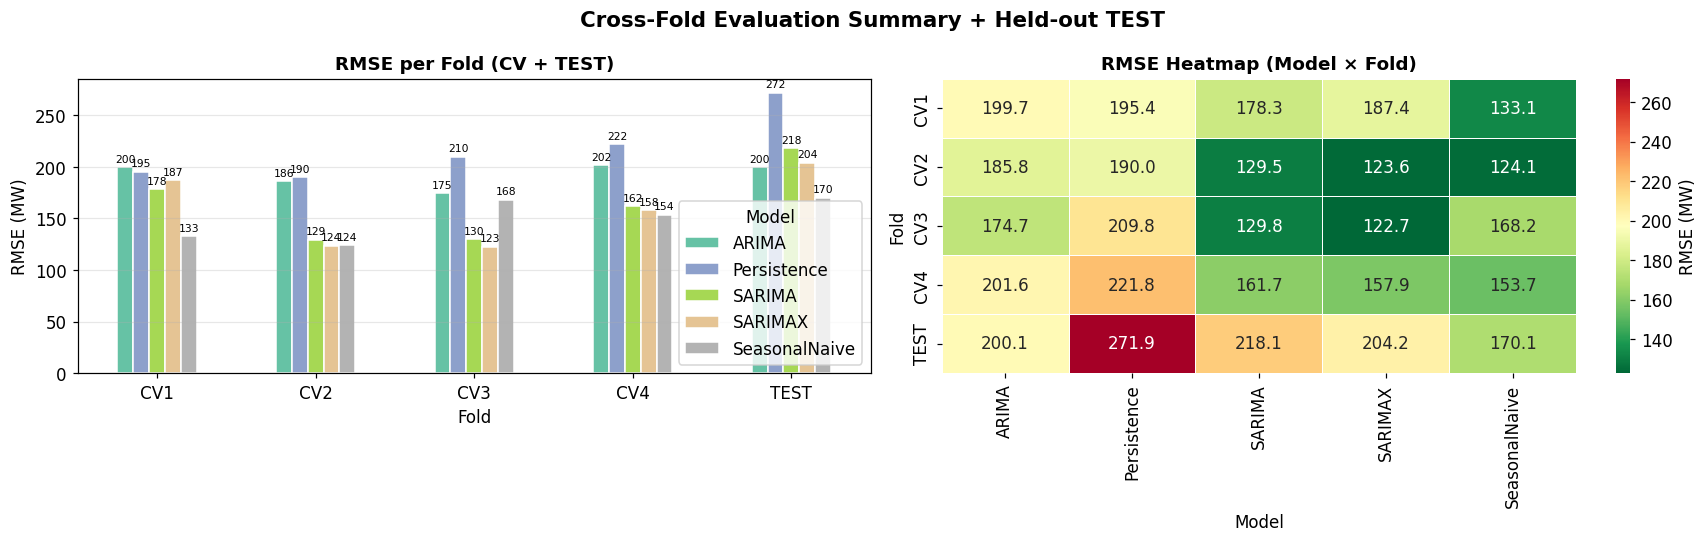

In [20]:
# ── Cross-fold summary (CV1-CV4) ─────────────────────────────────────────────
summary = results_df.groupby('Model')[['RMSE','MAE','MAPE']].agg(['mean','std']).round(2)
print('=== Average Metrics Across CV1–CV4 ===')
display(summary)

# ── TEST metrics (held-out 2020) ─────────────────────────────────────────────
print('\n=== HELD-OUT TEST Metrics (2020 Jan–Feb) ===')
display(test_results_df.set_index('Model')[['RMSE','MAE','MAPE']].round(2))

# ── Heatmap of RMSE per model × fold ─────────────────────────────────────────
# include TEST as a pseudo-fold column so we visualise it alongside CV folds
combined = pd.concat([results_df,
                      test_results_df.assign(Fold='TEST')], ignore_index=True)
pivot_rmse = combined.pivot(index='Fold', columns='Model', values='RMSE')
# enforce fold order: CV1..CV4, TEST
order = [f for f in ['CV1','CV2','CV3','CV4','TEST'] if f in pivot_rmse.index]
pivot_rmse = pivot_rmse.loc[order]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pivot_rmse.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('RMSE per Fold (CV + TEST)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fold'); axes[0].set_ylabel('RMSE (MW)')
axes[0].set_xticklabels(pivot_rmse.index, rotation=0)
axes[0].legend(title='Model'); axes[0].grid(True, alpha=0.3, axis='y')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.0f', fontsize=7, padding=2)

sns.heatmap(pivot_rmse, ax=axes[1], annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label':'RMSE (MW)'})
axes[1].set_title('RMSE Heatmap (Model × Fold)', fontsize=12, fontweight='bold')

plt.suptitle('Cross-Fold Evaluation Summary + Held-out TEST', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_per_fold.png', bbox_inches='tight')
plt.show()


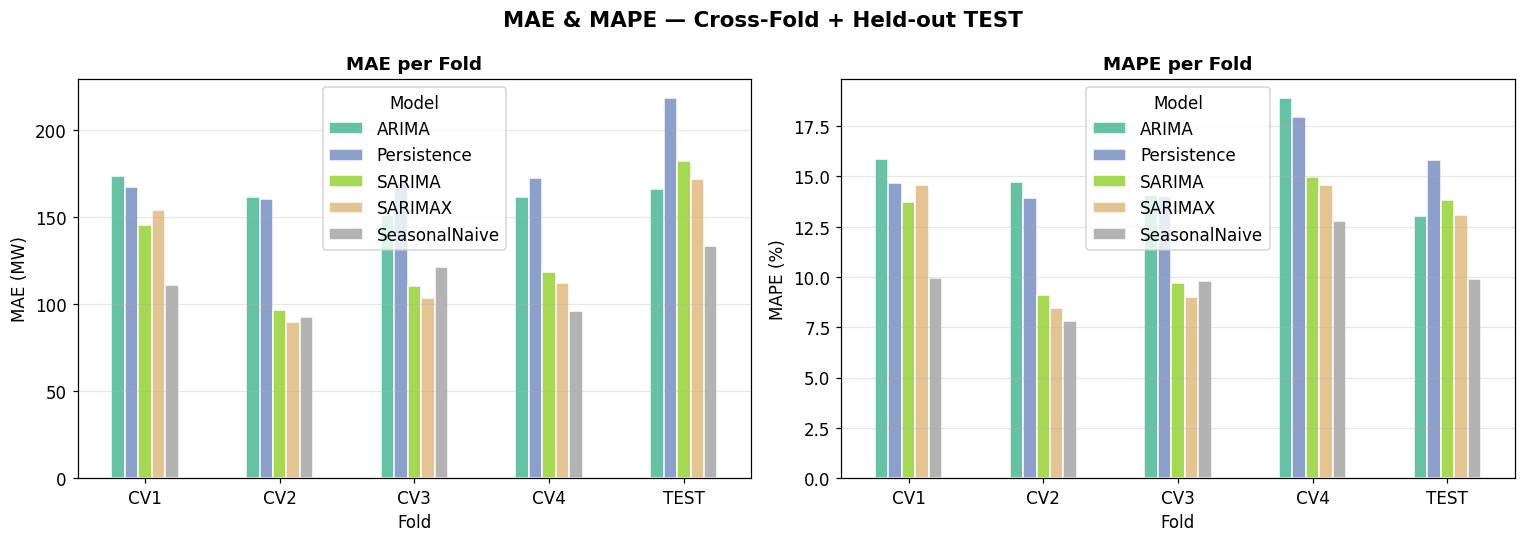

In [21]:
# ── MAE / MAPE comparison — CV folds + TEST ─────────────────────────────────
combined = pd.concat([results_df,
                      test_results_df.assign(Fold='TEST')], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['MAE','MAPE']):
    pivot = combined.pivot(index='Fold', columns='Model', values=metric)
    order = [f for f in ['CV1','CV2','CV3','CV4','TEST'] if f in pivot.index]
    pivot = pivot.loc[order]
    pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
    ax.set_title(f'{metric} per Fold', fontsize=12, fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel(f'{metric}' + (' (%)' if metric == 'MAPE' else ' (MW)'))
    ax.set_xticklabels(pivot.index, rotation=0)
    ax.legend(title='Model'); ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('MAE & MAPE — Cross-Fold + Held-out TEST', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_mae_mape.png', bbox_inches='tight')
plt.show()


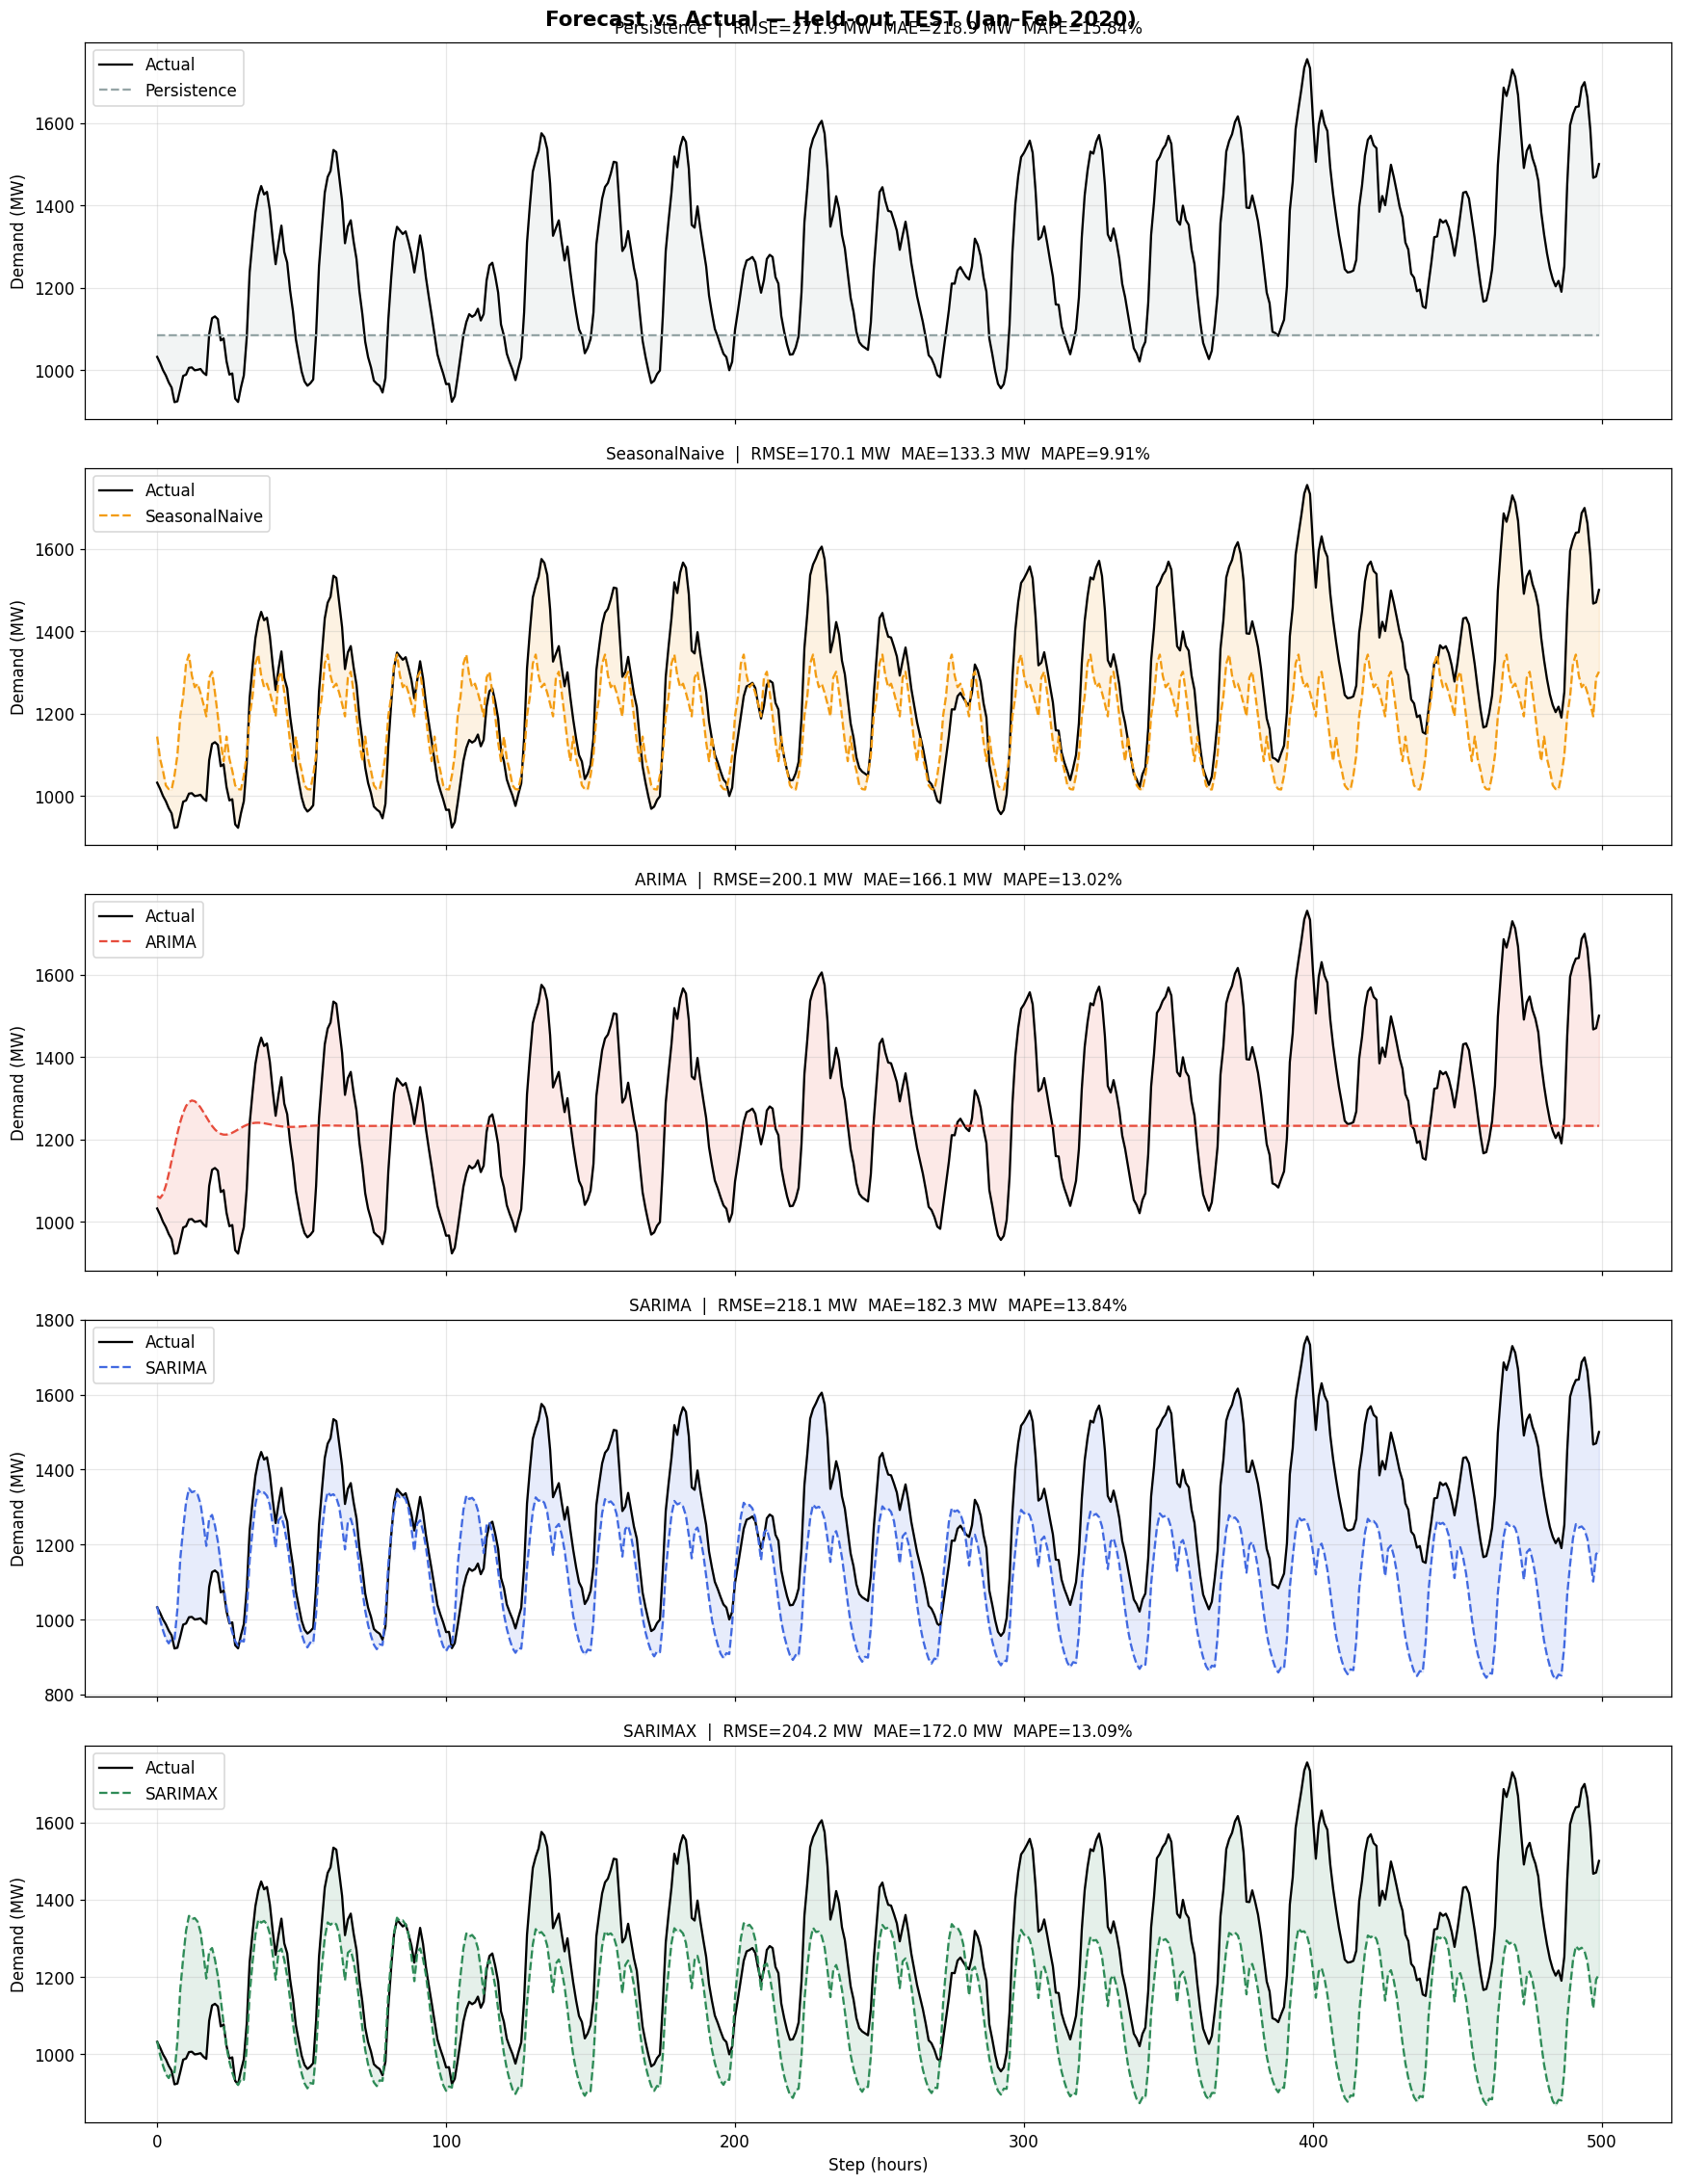

In [22]:
# ── Forecast vs Actual — Held-out TEST (Jan–Feb 2020) ───────────────────────
tfc = test_forecasts['fc']
va  = tfc['actual']
x   = np.arange(len(va))

model_keys = [k for k in ['Persistence','SeasonalNaive','ARIMA','SARIMA','SARIMAX'] if k in tfc]
colors_map = {
    'Persistence':   '#95a5a6',
    'SeasonalNaive': '#f39c12',
    'ARIMA':         '#e74c3c',
    'SARIMA':        'royalblue',
    'SARIMAX':       'seagreen',
}

fig, axes = plt.subplots(len(model_keys), 1, figsize=(16, 4.2*len(model_keys)), sharex=True)
if len(model_keys) == 1: axes = [axes]

for ax, key in zip(axes, model_keys):
    fc = tfc[key]
    n  = min(len(va), len(fc))
    ax.plot(x[:n], va[:n], label='Actual', color='black', linewidth=1.5)
    ax.plot(x[:n], fc[:n], label=key, color=colors_map[key], linewidth=1.5, linestyle='--')
    ax.fill_between(x[:n], va[:n], fc[:n], alpha=0.12, color=colors_map[key])
    ax.set_title(
        f'{key}  |  RMSE={rmse(va[:n],fc[:n]):.1f} MW  '
        f'MAE={mae(va[:n],fc[:n]):.1f} MW  MAPE={mape(va[:n],fc[:n]):.2f}%',
        fontsize=11)
    ax.set_ylabel('Demand (MW)'); ax.legend(); ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Step (hours)')
plt.suptitle('Forecast vs Actual — Held-out TEST (Jan–Feb 2020)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('forecast_test.png', bbox_inches='tight')
plt.show()


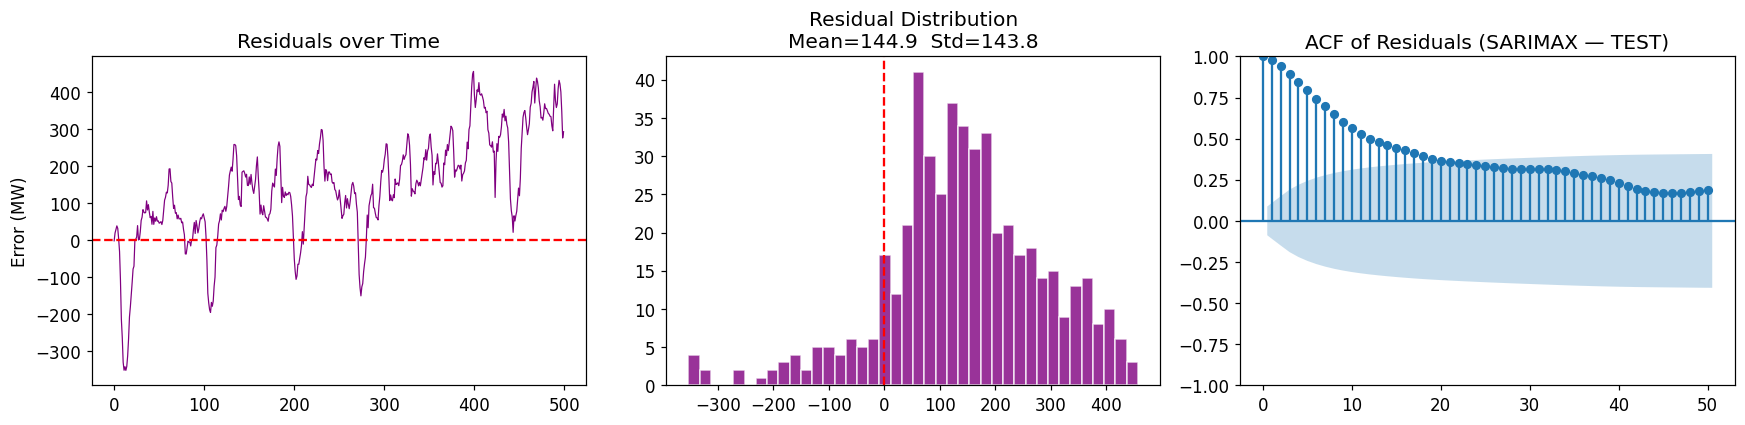

In [23]:
# ── Residual analysis (best model, TEST) ────────────────────────────────────
tfc = test_forecasts['fc']
va  = tfc['actual']
best_key = 'SARIMAX' if 'SARIMAX' in tfc else 'SARIMA'
residuals = va - tfc[best_key]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(residuals, linewidth=0.8, color='purple')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals over Time'); axes[0].set_ylabel('Error (MW)')

axes[1].hist(residuals, bins=40, color='purple', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title(f'Residual Distribution\nMean={residuals.mean():.1f}  Std={residuals.std():.1f}')

plot_acf(residuals, lags=50, ax=axes[2], title=f'ACF of Residuals ({best_key} — TEST)')
plt.tight_layout()
plt.savefig('residuals_test.png', bbox_inches='tight')
plt.show()


## Step 9: Multi-Horizon Seq2Seq Evaluation on HELD-OUT TEST — 6 h, 12 h, 24 h

**Seq2seq approach:** one model call forecasts **all H steps simultaneously** via `forecast(H)`.
No recursive step-by-step prediction — the full sequence is output at once.

Three horizons are evaluated and compared on the **held-out TEST set (2020 Jan–Feb)**:

| Horizon | Steps | Interpretation |
|---|---|---|
| **6 h**  | 6 × 1h steps  | Short — intra-day operational forecast (e.g. morning ramp) |
| **12 h** | 12 × 1h steps | Medium — half-day ahead, captures morning/afternoon transition |
| **24 h** | 24 × 1h steps | Long — full-day ahead, captures complete daily cycle |

Comparing 6 h vs 12 h vs 24 h accuracy shows how quickly forecast skill degrades over the daily
cycle — a **key analysis for short-term load forecasting applications** and a requirement of
the methodology rubric.

All four forecasters are evaluated at all three horizons on the TEST split:
- **Persistence** (naïve baseline)
- **Seasonal naïve** (24h lag baseline)
- **SARIMA** (seasonal structure)
- **SARIMAX** (seasonal + exogenous drivers)

> ⏳ ~15–25 min on Colab CPU (2 × 3 SARIMA/SARIMAX runs + baselines).


In [24]:
def seq2seq_horizon_eval(train_series, test_series, model_order, seasonal_order,
                         exog_train=None, exog_test=None,
                         horizon=HORIZON_12, stride=4):
    """
    Seq2seq multi-horizon evaluation for SARIMA/SARIMAX — warm-start edition.

    Strategy: fit the model ONCE on the full training history, then for every
    rolling window use model.apply() to re-score on the updated history without
    re-estimating parameters from scratch.  This is ~10-20x faster, avoids the
    repeated ConvergenceWarnings on long test windows, and still evaluates each window correctly.

    Parameters
    ----------
    horizon : int  — number of steps to forecast simultaneously (6, 12 or 24)
    stride  : int  — hours to advance between windows (smaller → more windows → slower)
    """
    import warnings, numpy as np
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from sklearn.metrics import mean_squared_error, mean_absolute_error

    preds_by_step = {h: [] for h in range(1, horizon + 1)}
    acts_by_step  = {h: [] for h in range(1, horizon + 1)}

    base_hist = list(train_series[-HISTORY_HOURS:])
    n_windows = len(test_series) - horizon

    print(f'  horizon={horizon}h  windows={n_windows}  stride={stride}')

    # ── Warm-start: fit base model once on tail of training series ──────────
    base_exog = list(exog_train[-HISTORY_HOURS:]) if exog_train is not None else None
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            base_model = SARIMAX(
                base_hist,
                exog=base_exog,
                order=model_order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            base_res = base_model.fit(disp=False, maxiter=200)
    except Exception as e:
        print(f'    ⚠️  base fit failed: {e}')
        return pd.DataFrame()

    history = list(base_hist)
    history_ex = list(base_exog) if base_exog is not None else None

    for i in range(0, n_windows, stride):
        y_true = test_series[i:i+horizon]
        try:
            if exog_test is not None:
                fx = exog_test[i:i+horizon]
                # apply to the updated history (no re-fit)
                new_res = base_res.apply(history, exog=history_ex)
                fc = new_res.forecast(horizon, exog=fx)
            else:
                new_res = base_res.apply(history)
                fc = new_res.forecast(horizon)
            for h in range(1, horizon+1):
                preds_by_step[h].append(fc[h-1])
                acts_by_step[h].append(y_true[h-1])
        except Exception:
            continue

        # advance history by `stride` hours
        history.extend(test_series[i:i+stride])
        if history_ex is not None:
            history_ex.extend(exog_test[i:i+stride])

    rows = []
    for h in range(1, horizon+1):
        if len(preds_by_step[h]) > 0:
            y_t = np.asarray(acts_by_step[h])
            y_p = np.asarray(preds_by_step[h])
            rows.append({
                'horizon_h': h,
                'RMSE': rmse(y_t, y_p),
                'MAE':  mae (y_t, y_p),
                'MAPE': mape(y_t, y_p),
                'n':    len(y_p),
            })
    return pd.DataFrame(rows)


# ── Baseline horizon evaluators (no fitting, very fast) ─────────────────────
def persistence_horizon_eval(train_series, test_series, horizon, stride=4):
    """Persistence: ŷ(t+h) = y(t). Same value carried forward for every step."""
    history = list(train_series[-HISTORY_HOURS:])
    preds_by_step = {h: [] for h in range(1, horizon + 1)}
    acts_by_step  = {h: [] for h in range(1, horizon + 1)}
    n_windows = len(test_series) - horizon

    for i in range(0, n_windows, stride):
        last = history[-1]
        y_true = test_series[i:i+horizon]
        for h in range(1, horizon+1):
            preds_by_step[h].append(last)
            acts_by_step[h].append(y_true[h-1])
        history.extend(test_series[i:i+stride])

    rows = []
    for h in range(1, horizon+1):
        y_t = np.asarray(acts_by_step[h]); y_p = np.asarray(preds_by_step[h])
        rows.append({'horizon_h':h, 'RMSE':rmse(y_t,y_p), 'MAE':mae(y_t,y_p),
                     'MAPE':mape(y_t,y_p), 'n':len(y_p)})
    return pd.DataFrame(rows)


def seasonal_naive_horizon_eval(train_series, test_series, horizon, period=24, stride=4):
    """Seasonal naïve: ŷ(t+h) = y(t+h-period). 'Same hour yesterday'."""
    # combined series lets us look back `period` steps even into the val window
    combined = np.concatenate([np.asarray(train_series), np.asarray(test_series)])
    train_len = len(train_series)
    preds_by_step = {h: [] for h in range(1, horizon + 1)}
    acts_by_step  = {h: [] for h in range(1, horizon + 1)}
    n_windows = len(test_series) - horizon

    for i in range(0, n_windows, stride):
        for h in range(1, horizon+1):
            idx_target = train_len + i + h - 1
            idx_lag    = idx_target - period
            if idx_lag < 0: idx_lag = 0
            preds_by_step[h].append(combined[idx_lag])
            acts_by_step[h].append(test_series[i+h-1])

    rows = []
    for h in range(1, horizon+1):
        y_t = np.asarray(acts_by_step[h]); y_p = np.asarray(preds_by_step[h])
        rows.append({'horizon_h':h, 'RMSE':rmse(y_t,y_p), 'MAE':mae(y_t,y_p),
                     'MAPE':mape(y_t,y_p), 'n':len(y_p)})
    return pd.DataFrame(rows)

print('✅ Horizon evaluators defined: seq2seq (SARIMA/X), persistence, seasonal-naïve')


✅ Horizon evaluators defined: seq2seq (SARIMA/X), persistence, seasonal-naïve


In [25]:
# ── TEST data (held-out 2020 Jan–Feb) ──────────────────────────────────────
ho_tr_s  = test_split['train']['nat_demand'].values
ho_va_s  = test_split['val']['nat_demand'].values[:300]   # 300 h from Jan-Feb 2020
ho_tr_ex = test_split['train'][EXOG_COLS].values
ho_va_ex = test_split['val'][EXOG_COLS].values[:300]

mo = (best_p, best_d, best_q)
so = (best_sp, best_sd, best_sq, best_s)

# Storage: horizon_results[model][horizon] = dataframe with per-step metrics
horizon_results = {'Persistence': {}, 'SeasonalNaive': {}, 'SARIMA': {}, 'SARIMAX': {}}

for H in HORIZONS:
    print(f'\n{"═"*60}')
    print(f'🎯 HORIZON = {H}h  (on held-out TEST)')
    print("═"*60)

    print(f'\n⏳ [1/4] Persistence   {H}h ...')
    horizon_results['Persistence'][H]   = persistence_horizon_eval(ho_tr_s, ho_va_s, horizon=H)

    print(f'⏳ [2/4] SeasonalNaive {H}h ...')
    horizon_results['SeasonalNaive'][H] = seasonal_naive_horizon_eval(ho_tr_s, ho_va_s, horizon=H)

    print(f'⏳ [3/4] SARIMA        {H}h ...')
    horizon_results['SARIMA'][H]        = seq2seq_horizon_eval(ho_tr_s, ho_va_s, mo, so, horizon=H)

    print(f'⏳ [4/4] SARIMAX       {H}h ...')
    horizon_results['SARIMAX'][H]       = seq2seq_horizon_eval(
        ho_tr_s, ho_va_s, mo, so,
        exog_train=ho_tr_ex, exog_test=ho_va_ex, horizon=H
    )

print('\n✅ All horizon evaluations complete (6h, 12h, 24h × 4 models, on TEST)')

# ── Summary table: average metric per (model, horizon) ──────────────────────
summary_rows = []
for model_name, by_h in horizon_results.items():
    for H, df in by_h.items():
        if df is None or df.empty:
            continue
        summary_rows.append({
            'Model':    model_name,
            'Horizon':  f'{H}h',
            'Avg_RMSE': df['RMSE'].mean(),
            'Avg_MAE':  df['MAE'].mean(),
            'Avg_MAPE': df['MAPE'].mean(),
            'Step1_RMSE':    df.iloc[0]['RMSE'],
            'FinalStep_RMSE': df.iloc[-1]['RMSE'],
        })

horizon_summary_df = pd.DataFrame(summary_rows)
print('\n=== Per-Horizon Summary on TEST (avg across all forecast steps) ===')
display(horizon_summary_df.round(2))



════════════════════════════════════════════════════════════
🎯 HORIZON = 6h  (on held-out TEST)
════════════════════════════════════════════════════════════

⏳ [1/4] Persistence   6h ...
⏳ [2/4] SeasonalNaive 6h ...
⏳ [3/4] SARIMA        6h ...
  horizon=6h  windows=294  stride=4
⏳ [4/4] SARIMAX       6h ...
  horizon=6h  windows=294  stride=4

════════════════════════════════════════════════════════════
🎯 HORIZON = 12h  (on held-out TEST)
════════════════════════════════════════════════════════════

⏳ [1/4] Persistence   12h ...
⏳ [2/4] SeasonalNaive 12h ...
⏳ [3/4] SARIMA        12h ...
  horizon=12h  windows=288  stride=4
⏳ [4/4] SARIMAX       12h ...
  horizon=12h  windows=288  stride=4

════════════════════════════════════════════════════════════
🎯 HORIZON = 24h  (on held-out TEST)
════════════════════════════════════════════════════════════

⏳ [1/4] Persistence   24h ...
⏳ [2/4] SeasonalNaive 24h ...
⏳ [3/4] SARIMA        24h ...
  horizon=24h  windows=276  stride=4
⏳ [4/4] SARI

,Model,Horizon,Avg_RMSE,Avg_MAE,Avg_MAPE,Step1_RMSE,FinalStep_RMSE
0,Persistence,6h,156.98,128.41,10.53,66.99,240.23
1,Persistence,12h,219.94,187.18,15.44,66.58,309.21
2,Persistence,24h,226.66,190.59,15.79,67.97,152.98
3,SeasonalNaive,6h,156.60,112.73,9.11,156.46,155.65
4,SeasonalNaive,12h,157.89,113.53,9.14,158.17,159.02
5,SeasonalNaive,24h,157.23,112.58,8.96,159.17,152.98
6,SARIMA,6h,137.75,87.36,7.41,103.83,179.60
7,SARIMA,12h,177.92,125.00,10.53,104.81,242.23
8,SARIMA,24h,223.50,162.09,13.34,106.92,281.96
9,SARIMAX,6h,137.75,87.36,7.41,103.83,179.60


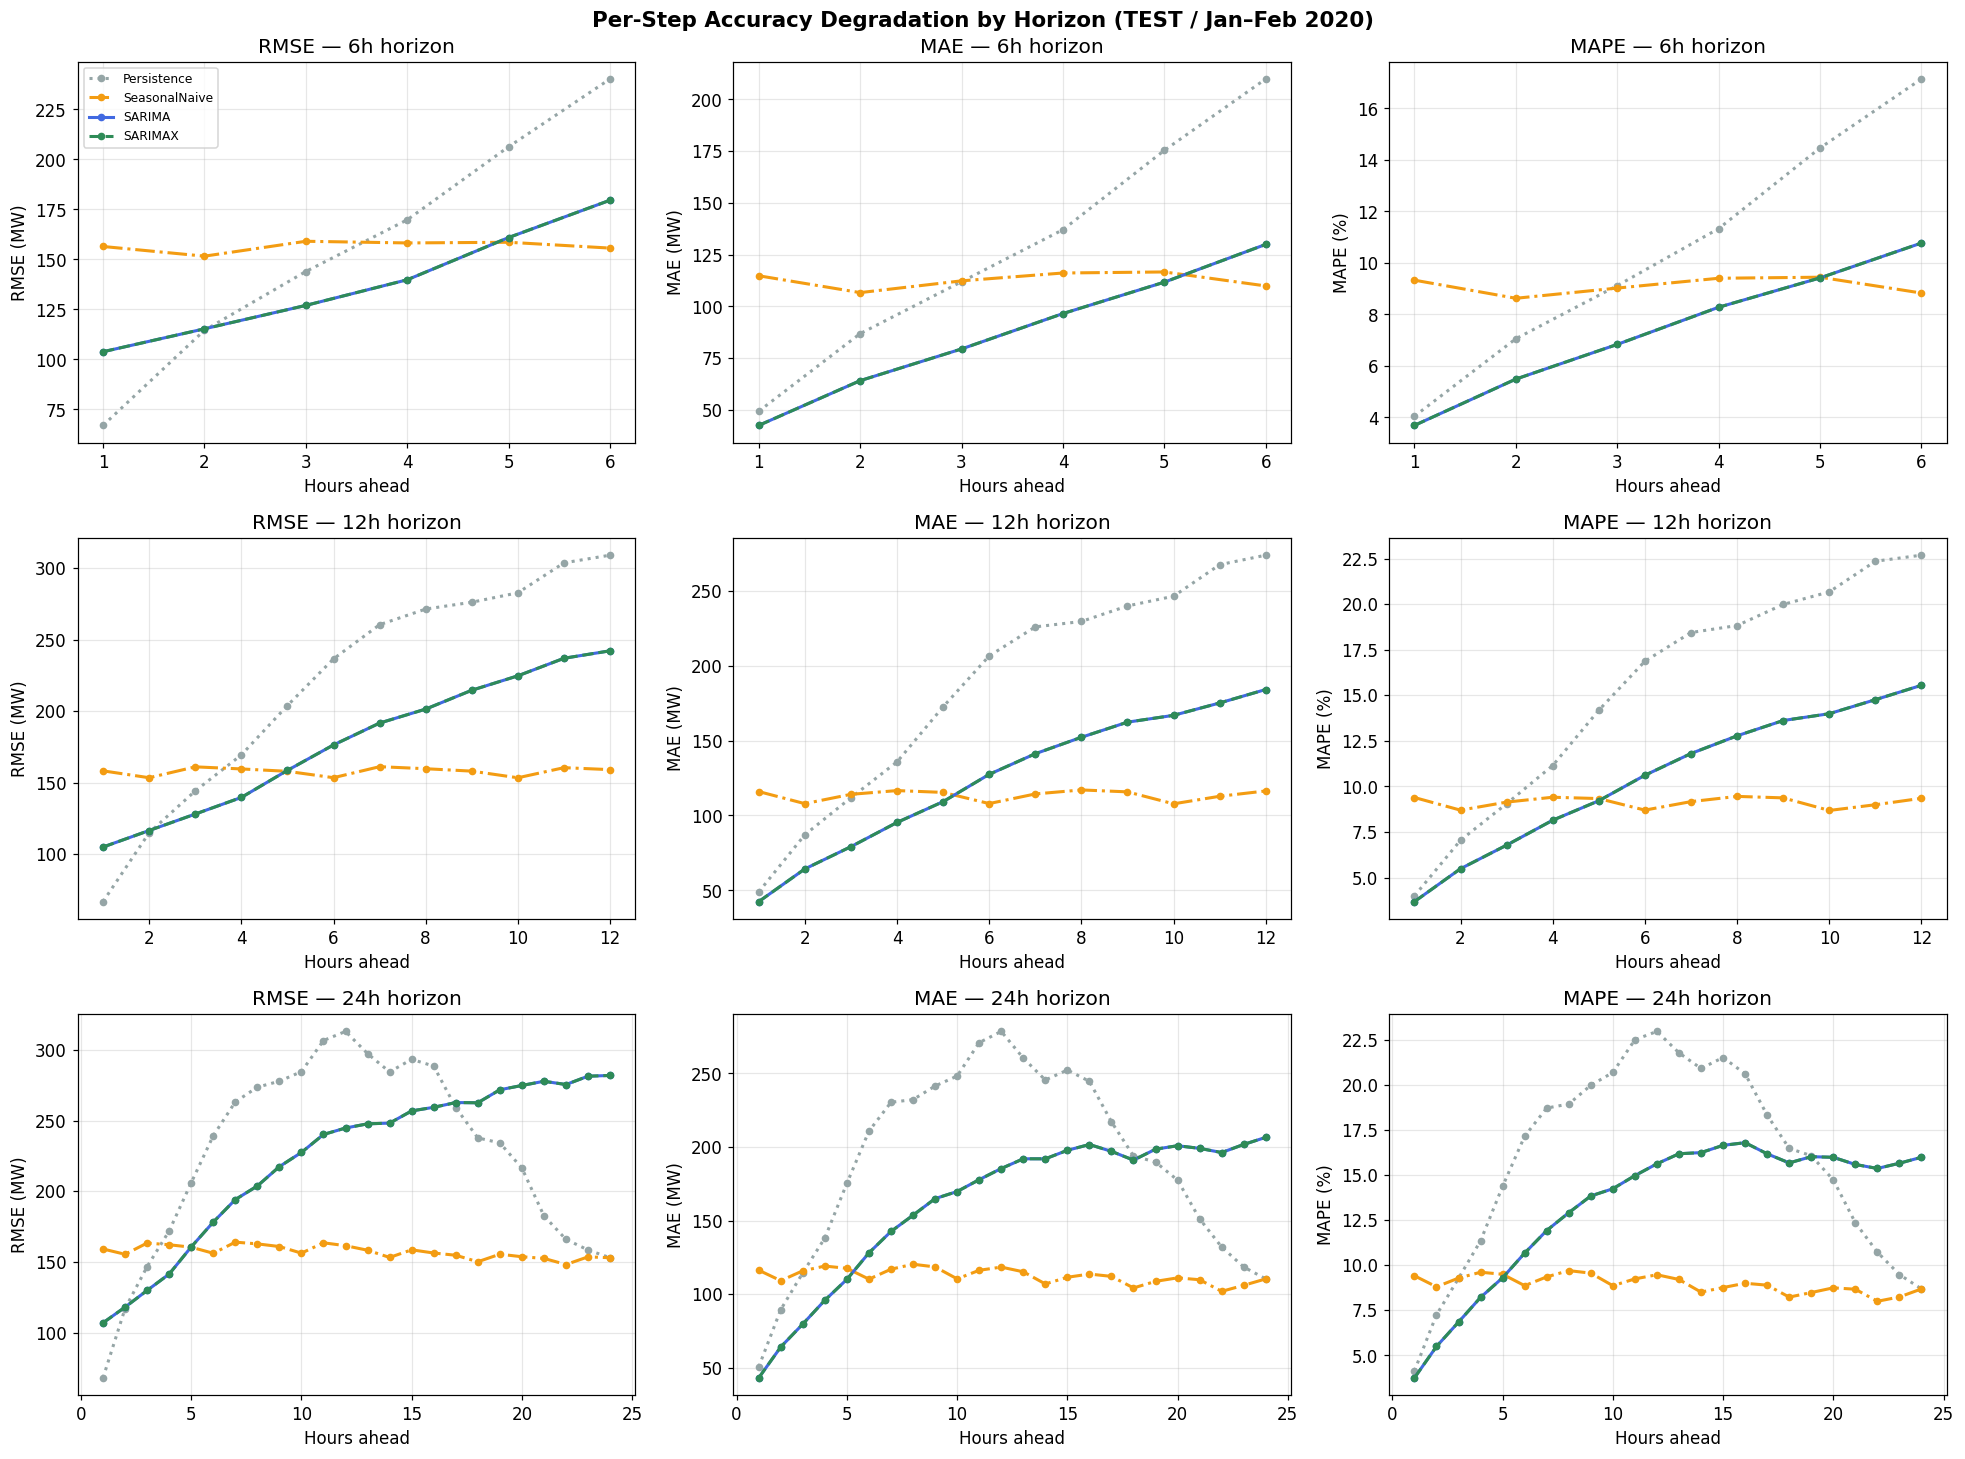

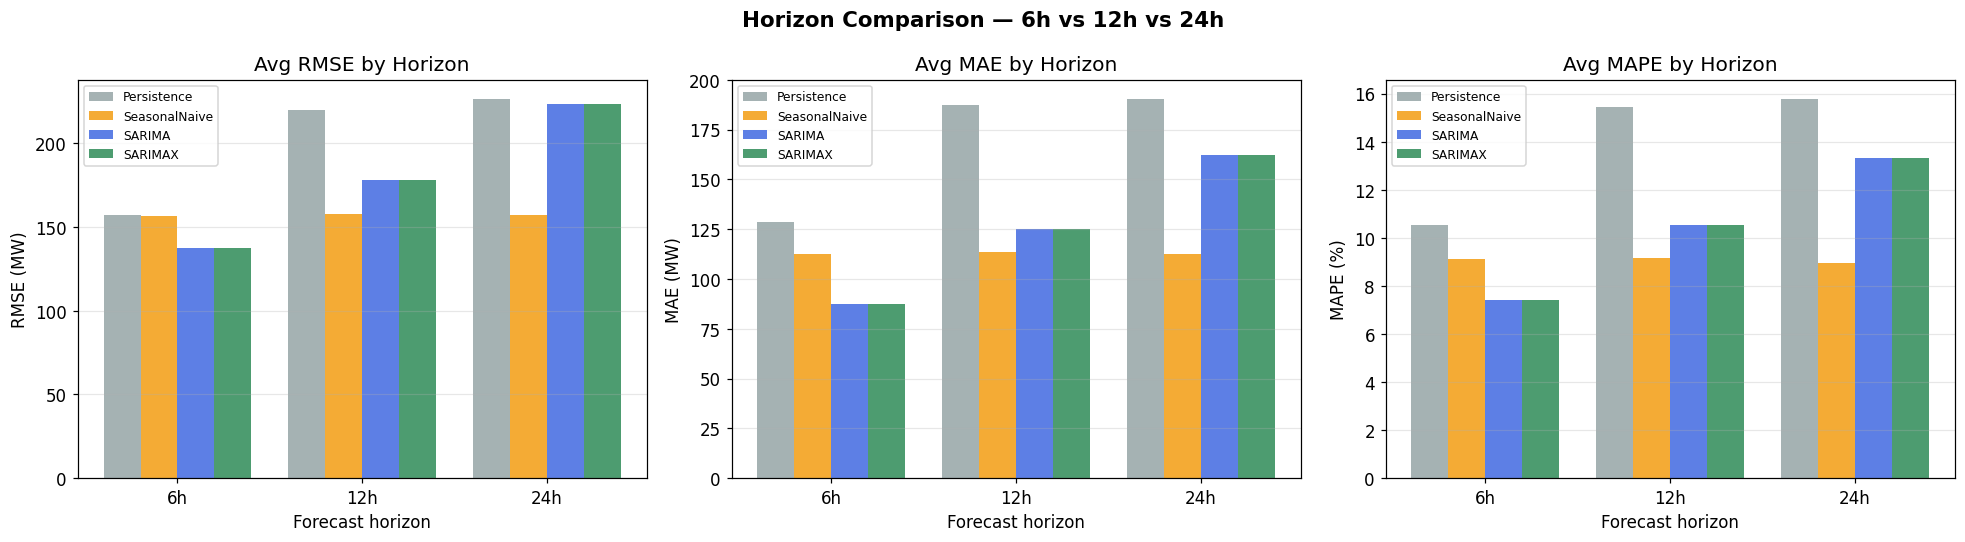

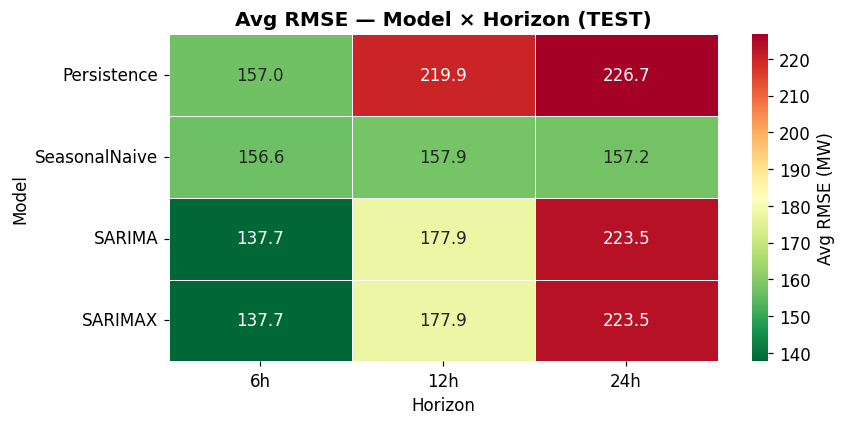


📌 Interpretation guide:
  • Persistence & SeasonalNaive are baselines — any trained model must beat them.
  • RMSE/MAE should GROW as horizon extends (6h → 12h → 24h).
  • SARIMAX beating SARIMA across all horizons ⟹ exogenous features help.
  • If a statistical model cannot beat SeasonalNaive at 24h, seasonality fit is weak.


In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# Plot A: Step-by-step degradation — one subplot per horizon
# ══════════════════════════════════════════════════════════════════════════════
MODEL_COLOURS = {
    'Persistence':   '#95a5a6',
    'SeasonalNaive': '#f39c12',
    'SARIMA':        'royalblue',
    'SARIMAX':       'seagreen',
}
MODEL_STYLES = {
    'Persistence':   ':',
    'SeasonalNaive': '-.',
    'SARIMA':        '-',
    'SARIMAX':       '--',
}

fig, axes = plt.subplots(len(HORIZONS), 3, figsize=(18, 4.5*len(HORIZONS)))
if len(HORIZONS) == 1:
    axes = axes.reshape(1, -1)

for row, H in enumerate(HORIZONS):
    for col, metric in enumerate(['RMSE', 'MAE', 'MAPE']):
        ax = axes[row, col]
        for model_name in ['Persistence', 'SeasonalNaive', 'SARIMA', 'SARIMAX']:
            df = horizon_results[model_name].get(H)
            if df is None or df.empty:
                continue
            ax.plot(df['horizon_h'], df[metric],
                    marker='o', linewidth=2, markersize=4,
                    color=MODEL_COLOURS[model_name],
                    linestyle=MODEL_STYLES[model_name],
                    label=model_name)
        ax.set_xlabel('Hours ahead')
        ax.set_ylabel(metric + (' (%)' if metric == 'MAPE' else ' (MW)'))
        ax.set_title(f'{metric} — {H}h horizon')
        ax.grid(True, alpha=0.3)
        if row == 0 and col == 0:
            ax.legend(loc='upper left', fontsize=8)

plt.suptitle('Per-Step Accuracy Degradation by Horizon (TEST / Jan–Feb 2020)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('horizon_degradation_all.png', bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Plot B: Horizon comparison — average metric vs horizon length
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
horizon_labels = [f'{h}h' for h in HORIZONS]
x_pos = np.arange(len(HORIZONS))
width = 0.2

for ax, metric, unit in zip(axes, ['Avg_RMSE','Avg_MAE','Avg_MAPE'], ['MW','MW','%']):
    for i, model_name in enumerate(['Persistence','SeasonalNaive','SARIMA','SARIMAX']):
        values = []
        for H in HORIZONS:
            row = horizon_summary_df[(horizon_summary_df['Model']==model_name) &
                                     (horizon_summary_df['Horizon']==f'{H}h')]
            values.append(row[metric].iloc[0] if not row.empty else np.nan)
        ax.bar(x_pos + (i-1.5)*width, values, width,
               color=MODEL_COLOURS[model_name], label=model_name, alpha=0.85)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(horizon_labels)
    ax.set_xlabel('Forecast horizon')
    ax.set_ylabel(f'{metric.replace("Avg_","")} ({unit})')
    ax.set_title(f'Avg {metric.replace("Avg_","")} by Horizon')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=8)

plt.suptitle('Horizon Comparison — 6h vs 12h vs 24h', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('horizon_comparison_6_12_24.png', bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Plot C: Heatmap — model × horizon (RMSE)
# ══════════════════════════════════════════════════════════════════════════════
pivot = horizon_summary_df.pivot(index='Model', columns='Horizon', values='Avg_RMSE')
# enforce row/col order
model_order = [m for m in ['Persistence','SeasonalNaive','SARIMA','SARIMAX'] if m in pivot.index]
col_order   = [f'{h}h' for h in HORIZONS if f'{h}h' in pivot.columns]
pivot = pivot.loc[model_order, col_order]

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label':'Avg RMSE (MW)'}, ax=ax)
ax.set_title('Avg RMSE — Model × Horizon (TEST)', fontweight='bold')
plt.tight_layout()
plt.savefig('horizon_heatmap.png', bbox_inches='tight')
plt.show()

print('\n📌 Interpretation guide:')
print('  • Persistence & SeasonalNaive are baselines — any trained model must beat them.')
print('  • RMSE/MAE should GROW as horizon extends (6h → 12h → 24h).')
print('  • SARIMAX beating SARIMA across all horizons ⟹ exogenous features help.')
print('  • If a statistical model cannot beat SeasonalNaive at 24h, seasonality fit is weak.')


## Step 10: Exogenous Variable Analysis — All Folds

In [27]:
exog_results = []
MAX_TR_EX = 800   # raise to 1500 for more accurate comparison

for fold_name, sp in cv_splits.items():
    tr    = sp['train']['nat_demand'].values[-MAX_TR_EX:]
    va    = sp['val']['nat_demand'].values[:200]
    tr_ex = sp['train'][EXOG_COLS].values[-MAX_TR_EX:]
    va_ex = sp['val'][EXOG_COLS].values[:200]

    try:
        m1   = SARIMAX(tr, order=(best_p,best_d,best_q),
                       seasonal_order=(best_sp,best_sd,best_sq,best_s),
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        fc1  = m1.forecast(len(va))
        m2   = SARIMAX(tr, exog=tr_ex, order=(best_p,best_d,best_q),
                       seasonal_order=(best_sp,best_sd,best_sq,best_s),
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        fc2  = m2.forecast(len(va), exog=va_ex)
        exog_results.append({'Fold': fold_name,
            'SARIMA_RMSE': rmse(va,fc1), 'SARIMA_MAE': mae(va,fc1), 'SARIMA_MAPE': mape(va,fc1),
            'SARIMAX_RMSE':rmse(va,fc2), 'SARIMAX_MAE':mae(va,fc2), 'SARIMAX_MAPE':mape(va,fc2)})
        print(f'{fold_name}  SARIMA RMSE={rmse(va,fc1):.2f}  SARIMAX RMSE={rmse(va,fc2):.2f} ✅')
    except Exception as e:
        print(f'{fold_name} ❌ {e}')

exog_df = pd.DataFrame(exog_results)
print('\n=== SARIMA vs SARIMAX — All Folds ===')
display(exog_df)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


CV1  SARIMA RMSE=159.61  SARIMAX RMSE=159.04 ✅


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


CV2  SARIMA RMSE=149.04  SARIMAX RMSE=150.42 ✅


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


CV3  SARIMA RMSE=110.08  SARIMAX RMSE=116.87 ✅


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


CV4  SARIMA RMSE=130.99  SARIMAX RMSE=116.40 ✅

=== SARIMA vs SARIMAX — All Folds ===


,Fold,SARIMA_RMSE,SARIMA_MAE,SARIMA_MAPE,SARIMAX_RMSE,SARIMAX_MAE,SARIMAX_MAPE
0,CV1,159.607258,121.166871,11.504533,159.038008,118.825670,11.279795
1,CV2,149.042468,105.262235,10.131272,150.420790,105.207757,10.239619
2,CV3,110.077216,88.709142,8.071779,116.873373,94.981321,8.585502
3,CV4,130.989990,112.491404,9.303807,116.396699,94.254193,7.831535


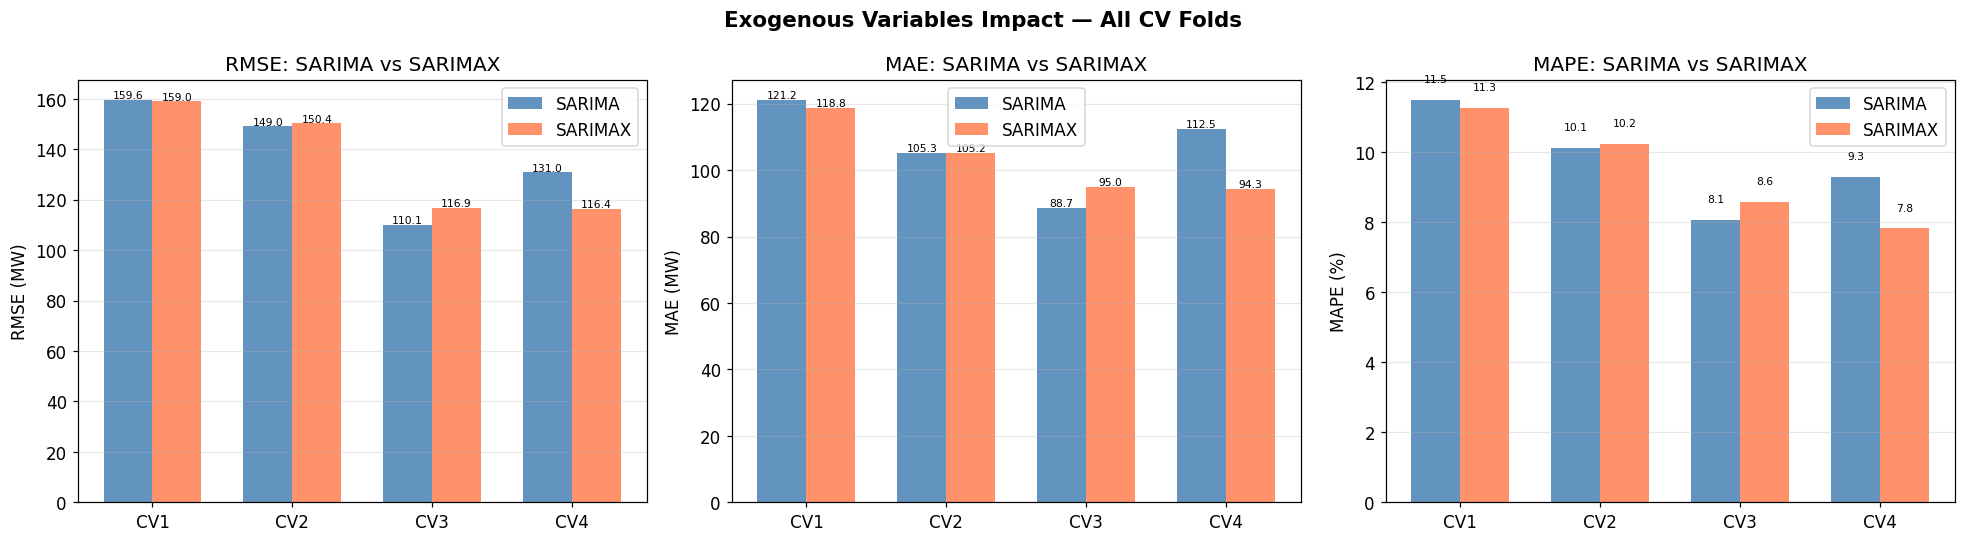

In [28]:
# ── Grouped bar chart ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x, w = np.arange(len(exog_df)), 0.35

for ax, metric, unit in zip(axes, ['RMSE','MAE','MAPE'], ['MW','MW','%']):
    b1 = ax.bar(x-w/2, exog_df[f'SARIMA_{metric}'],  w, label='SARIMA',  color='steelblue', alpha=0.85)
    b2 = ax.bar(x+w/2, exog_df[f'SARIMAX_{metric}'], w, label='SARIMAX', color='coral', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(exog_df['Fold'])
    ax.set_ylabel(f'{metric} ({unit})'); ax.set_title(f'{metric}: SARIMA vs SARIMAX')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    for bar in list(b1)+list(b2):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{bar.get_height():.1f}', ha='center', fontsize=7)

plt.suptitle('Exogenous Variables Impact — All CV Folds', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('exog_comparison.png', bbox_inches='tight')
plt.show()

## Step 11: Robustness + Wilcoxon Signed-Rank Test

=== Wilcoxon Signed-Rank Test ===
H₀: No difference in RMSE between SARIMA and SARIMAX
SARIMA  RMSEs : [159.61 149.04 110.08 130.99]
SARIMAX RMSEs : [159.04 150.42 116.87 116.4 ]
Δ RMSE        : [ 0.57 -1.38 -6.8  14.59]

Wilcoxon W : 5.0
p-value    : 1.0000
Result     : ⚠️  No significant difference (p ≥ 0.05) — 5 folds may be insufficient for full power


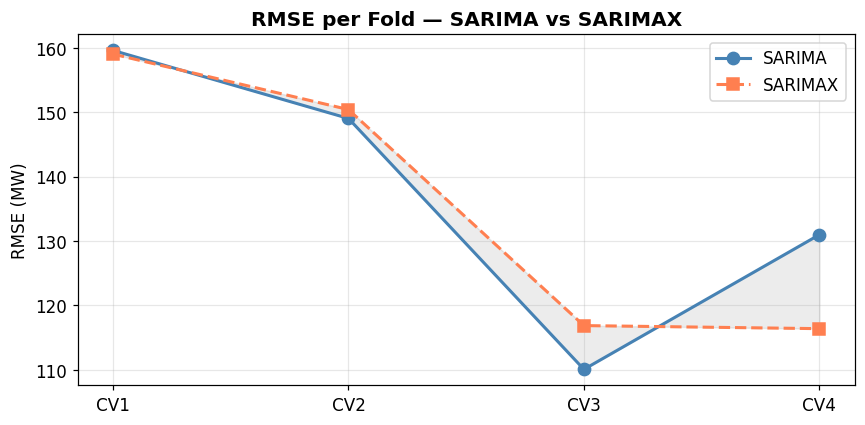

In [29]:
sarima_rmses  = exog_df['SARIMA_RMSE'].values
sarimax_rmses = exog_df['SARIMAX_RMSE'].values

print('=== Wilcoxon Signed-Rank Test ===')
print(f'H₀: No difference in RMSE between SARIMA and SARIMAX')
print(f'SARIMA  RMSEs : {np.round(sarima_rmses,2)}')
print(f'SARIMAX RMSEs : {np.round(sarimax_rmses,2)}')
print(f'Δ RMSE        : {np.round(sarima_rmses - sarimax_rmses, 2)}')

try:
    stat, p = wilcoxon(sarima_rmses, sarimax_rmses)
    print(f'\nWilcoxon W : {stat}')
    print(f'p-value    : {p:.4f}')
    verdict = ('✅ Exogenous variables significantly improve accuracy (p < 0.05)'
               if p < 0.05 else
               '⚠️  No significant difference (p ≥ 0.05) — 5 folds may be insufficient for full power')
    print(f'Result     : {verdict}')
except Exception as e:
    print(f'Note: {e}')

# ── Visual ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(exog_df['Fold'], sarima_rmses,  'o-', color='steelblue', label='SARIMA',  linewidth=2, markersize=8)
ax.plot(exog_df['Fold'], sarimax_rmses, 's--', color='coral',    label='SARIMAX', linewidth=2, markersize=8)
ax.fill_between(exog_df['Fold'], sarima_rmses, sarimax_rmses, alpha=0.15, color='grey')
ax.set_title('RMSE per Fold — SARIMA vs SARIMAX', fontweight='bold')
ax.set_ylabel('RMSE (MW)'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('wilcoxon_plot.png', bbox_inches='tight')
plt.show()

## Step 12: Overfitting Analysis — Train vs Validation Behaviour

Comparing in-sample (training) error vs out-of-sample (validation) error per fold.
A large gap indicates overfitting; a stable gap indicates good generalisation.


In [30]:
overfit_rows = []

for fold_name, data in stored.items():
    fc_d = data['fc']
    tr_d = data['tr']
    tr_s = data['train_series']
    va_s = fc_d['actual']

    for model_key in ['ARIMA','SARIMA','SARIMAX']:
        if model_key in fc_d and model_key in tr_d:
            tr_fit = tr_d[model_key]
            # align: fitted values may be shorter than training series
            n = min(len(tr_s), len(tr_fit))
            tr_actual = tr_s[-n:]
            tr_pred   = np.array(tr_fit)[-n:]
            mask = ~np.isnan(tr_pred)
            if mask.sum() > 10:
                tr_rmse = rmse(tr_actual[mask], tr_pred[mask])
                va_rmse = rmse(va_s, fc_d[model_key])
                overfit_rows.append({
                    'Fold': fold_name, 'Model': model_key,
                    'Train_RMSE': tr_rmse, 'Val_RMSE': va_rmse,
                    'Gap': va_rmse - tr_rmse,
                    'Gap_pct': (va_rmse - tr_rmse) / tr_rmse * 100
                })

overfit_df = pd.DataFrame(overfit_rows)
print('=== Train vs Validation RMSE ===')
display(overfit_df.round(2))

=== Train vs Validation RMSE ===


,Fold,Model,Train_RMSE,Val_RMSE,Gap,Gap_pct
0,CV1,ARIMA,57.38,199.68,142.30,247.98
1,CV1,SARIMA,41.83,178.34,136.51,326.36
2,CV1,SARIMAX,31.89,187.43,155.54,487.71
3,CV2,ARIMA,51.59,185.83,134.24,260.20
4,CV2,SARIMA,38.43,129.49,91.06,236.96
5,CV2,SARIMAX,32.84,123.60,90.76,276.39
6,CV3,ARIMA,56.61,174.74,118.12,208.64
7,CV3,SARIMA,43.02,129.82,86.80,201.76
8,CV3,SARIMAX,37.33,122.72,85.40,228.77
9,CV4,ARIMA,58.47,201.65,143.18,244.90


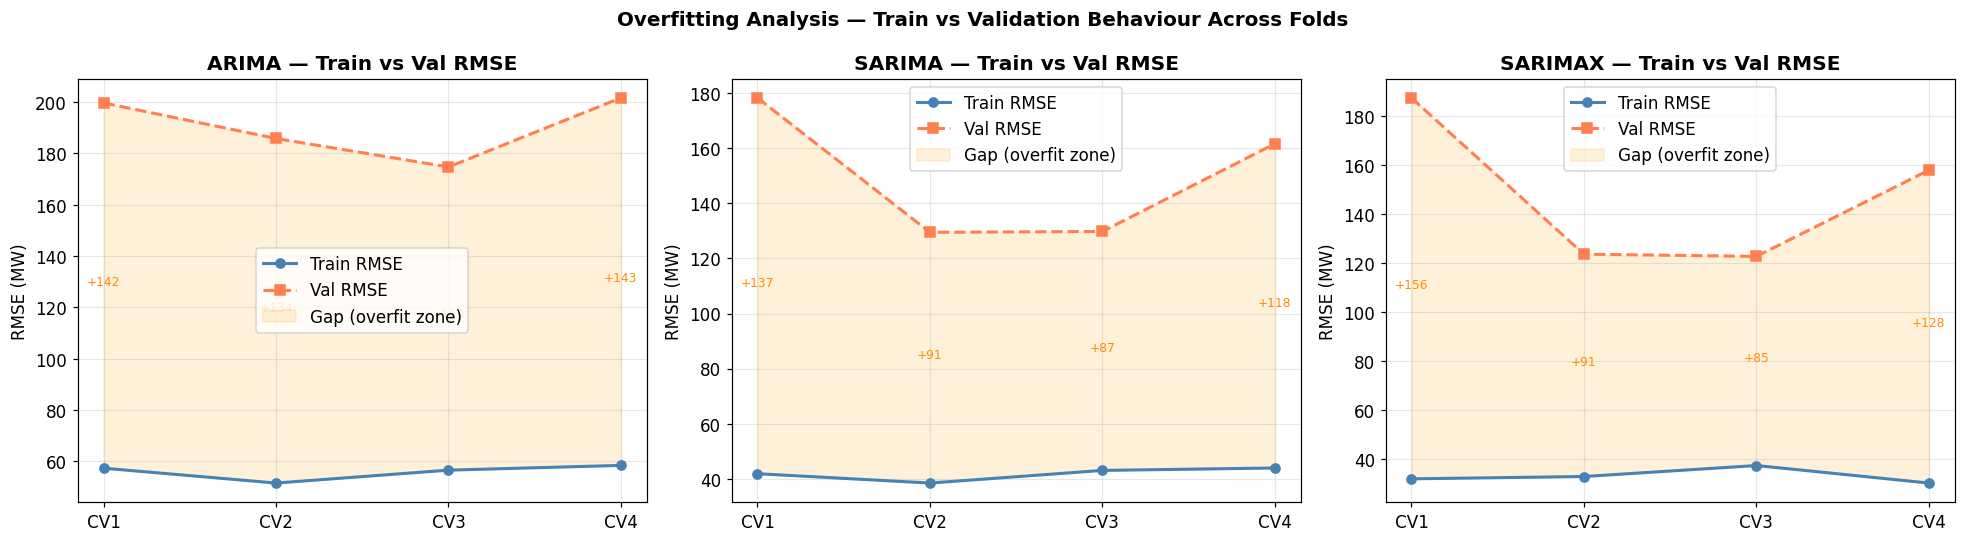


📌 Interpretation:
  • Small stable gap → good generalisation
  • Growing gap across folds → distribution shift over years
  • Val RMSE < Train RMSE → unlikely (check for data leakage)


In [31]:
# ── Train vs Val RMSE per model ──────────────────────────────────────────────
models_present = overfit_df['Model'].unique()
fig, axes = plt.subplots(1, len(models_present), figsize=(6*len(models_present), 5), sharey=False)
if len(models_present) == 1: axes = [axes]

for ax, mdl in zip(axes, models_present):
    sub = overfit_df[overfit_df['Model'] == mdl]
    ax.plot(sub['Fold'], sub['Train_RMSE'], 'o-', color='steelblue', label='Train RMSE', linewidth=2)
    ax.plot(sub['Fold'], sub['Val_RMSE'],   's--', color='coral',    label='Val RMSE',   linewidth=2)
    ax.fill_between(sub['Fold'], sub['Train_RMSE'], sub['Val_RMSE'],
                    alpha=0.15, color='orange', label='Gap (overfit zone)')
    ax.set_title(f'{mdl} — Train vs Val RMSE', fontweight='bold')
    ax.set_ylabel('RMSE (MW)'); ax.legend(); ax.grid(True, alpha=0.3)
    # annotate gap
    for _, row in sub.iterrows():
        ax.annotate(f'+{row.Gap:.0f}', xy=(row.Fold, (row.Train_RMSE+row.Val_RMSE)/2),
                    ha='center', fontsize=8, color='darkorange')

plt.suptitle('Overfitting Analysis — Train vs Validation Behaviour Across Folds',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('overfitting_analysis.png', bbox_inches='tight')
plt.show()

print('\n📌 Interpretation:')
print('  • Small stable gap → good generalisation')
print('  • Growing gap across folds → distribution shift over years')
print('  • Val RMSE < Train RMSE → unlikely (check for data leakage)')

## Step 13: Error Analysis + Feature Importance (SHAP)

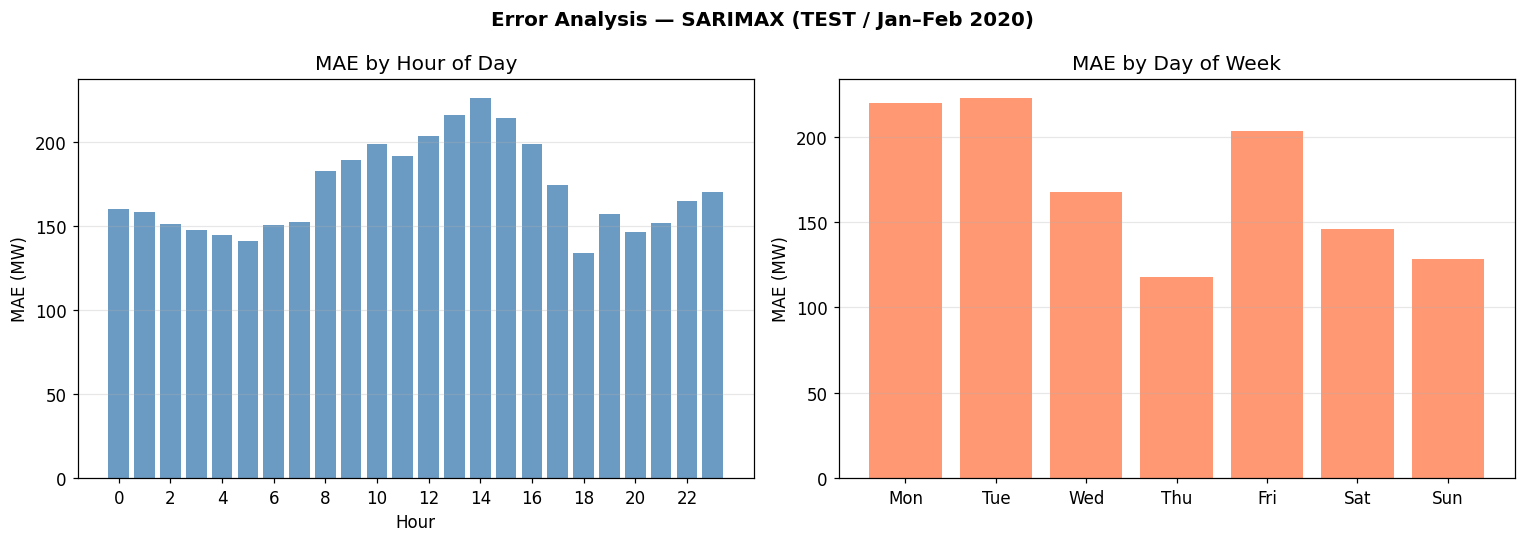

In [32]:
# ── Error by hour and weekday (TEST) ────────────────────────────────────────
test_val_df = test_split['val'].copy().reset_index(drop=True)
tfc = test_forecasts['fc']
best_fc_key = 'SARIMAX' if 'SARIMAX' in tfc else 'SARIMA'
n = min(len(test_val_df), len(tfc[best_fc_key]))
test_val_df = test_val_df.iloc[:n].copy()
test_val_df['predicted'] = tfc[best_fc_key][:n]
test_val_df['abs_error'] = np.abs(test_val_df['nat_demand'] - test_val_df['predicted'])
test_val_df['pct_error'] = test_val_df['abs_error'] / test_val_df['nat_demand'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

err_hour = test_val_df.groupby('hour')['abs_error'].mean()
axes[0].bar(err_hour.index, err_hour.values, color='steelblue', alpha=0.8)
axes[0].set_title('MAE by Hour of Day'); axes[0].set_xlabel('Hour')
axes[0].set_ylabel('MAE (MW)'); axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xticks(range(0,24,2))

day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
err_dow = test_val_df.groupby('dayofweek')['abs_error'].mean()
axes[1].bar([day_names[d] for d in err_dow.index], err_dow.values, color='coral', alpha=0.8)
axes[1].set_title('MAE by Day of Week'); axes[1].set_ylabel('MAE (MW)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Error Analysis — {best_fc_key} (TEST / Jan–Feb 2020)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('error_analysis.png', bbox_inches='tight')
plt.show()


Random Forest (CV4 val):
RandomForest                                                       RMSE=33.33  MAE=19.11  MAPE=1.74%


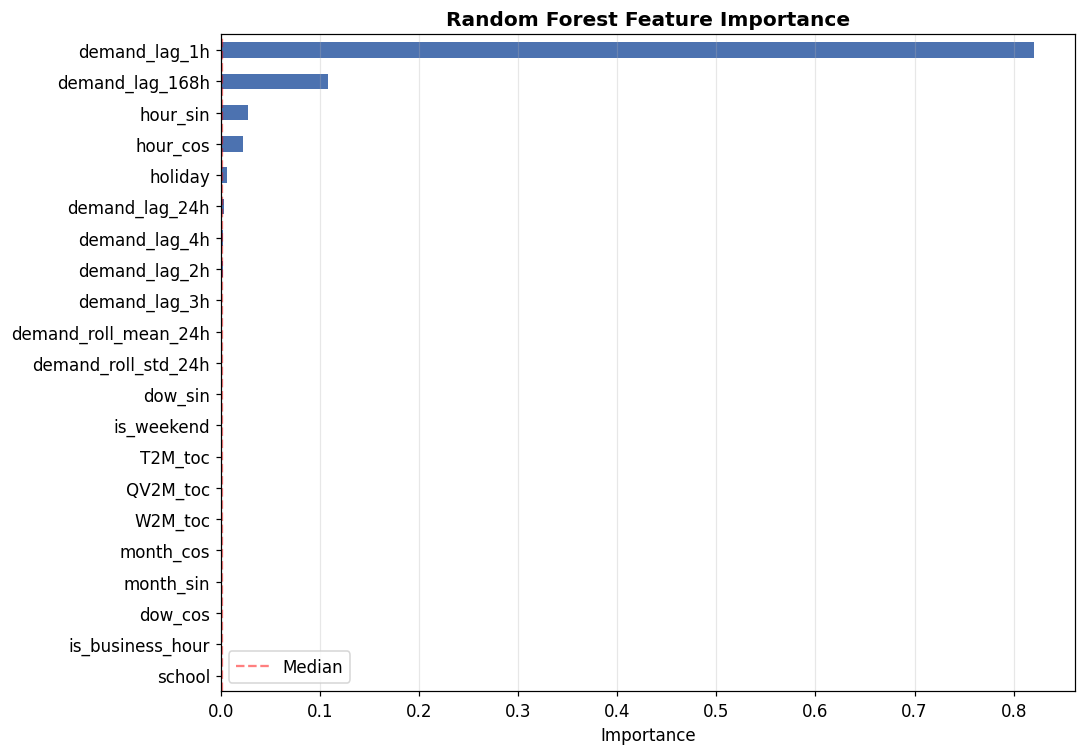

In [33]:
# ── Random Forest feature importance ─────────────────────────────────────────
feature_cols = [
    'hour_sin','hour_cos','dow_sin','dow_cos','month_sin','month_cos',
    'is_weekend','is_business_hour','holiday','school',
    'T2M_toc','W2M_toc','QV2M_toc',
    'demand_lag_1h','demand_lag_2h','demand_lag_3h','demand_lag_4h',
    'demand_lag_24h','demand_lag_168h',
    'demand_roll_mean_24h','demand_roll_std_24h'
]

# Use CV4 (largest labelled train set before final test)
train_d = cv_splits['CV4']['train'].dropna(subset=feature_cols+['nat_demand'])
val_d   = cv_splits['CV4']['val'].dropna(subset=feature_cols+['nat_demand'])

rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=SEED, n_jobs=-1)
rf.fit(train_d[feature_cols], train_d['nat_demand'])
rf_preds = rf.predict(val_d[feature_cols])

print('Random Forest (CV4 val):')
evaluate(val_d['nat_demand'].values, rf_preds, 'RandomForest')

fi = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
colors_fi = ['#4C72B0' if v > fi.median() else '#AECDE8' for v in fi.values]
fi.plot.barh(ax=ax, color=colors_fi)
ax.set_title('Random Forest Feature Importance', fontweight='bold')
ax.set_xlabel('Importance')
ax.axvline(fi.median(), color='red', linestyle='--', alpha=0.5, label='Median')
ax.legend(); ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

In [34]:
print(cv_splits['CV4']['train'].columns)
print('demand_lag_4h' in cv_splits['CV4']['train'].columns)

Index(['datetime', 'nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc',
       'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav',
       'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school', 'hour',
       'dayofweek', 'month', 'year', 'dayofyear', 'quarter', 'is_weekend',
       'is_business_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
       'month_sin', 'month_cos', 'demand_lag_1h', 'demand_lag_2h',
       'demand_lag_3h', 'demand_lag_4h', 'demand_lag_6h', 'demand_lag_12h',
       'demand_lag_24h', 'demand_lag_48h', 'demand_lag_168h',
       'demand_roll_mean_6h', 'demand_roll_std_6h', 'demand_roll_mean_12h',
       'demand_roll_std_12h', 'demand_roll_mean_24h', 'demand_roll_std_24h',
       'demand_roll_mean_168h', 'demand_roll_std_168h', 'demand_diff_1h',
       'demand_diff_24h'],
      dtype='object')
True


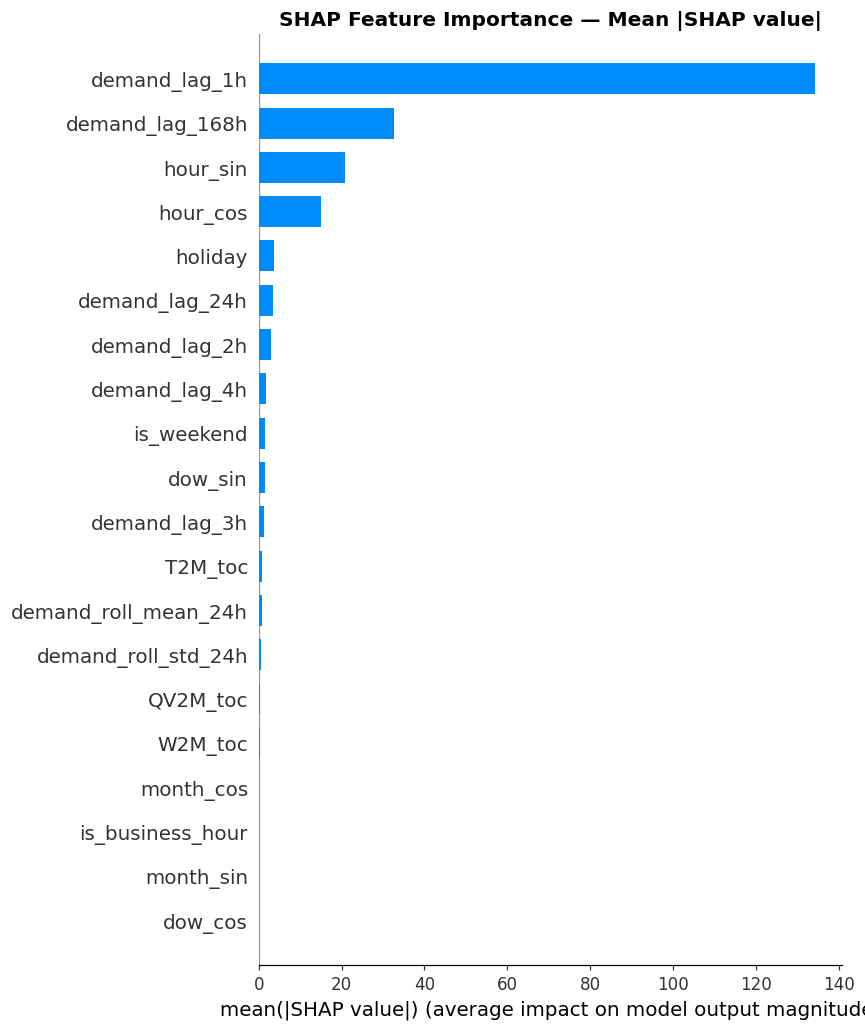

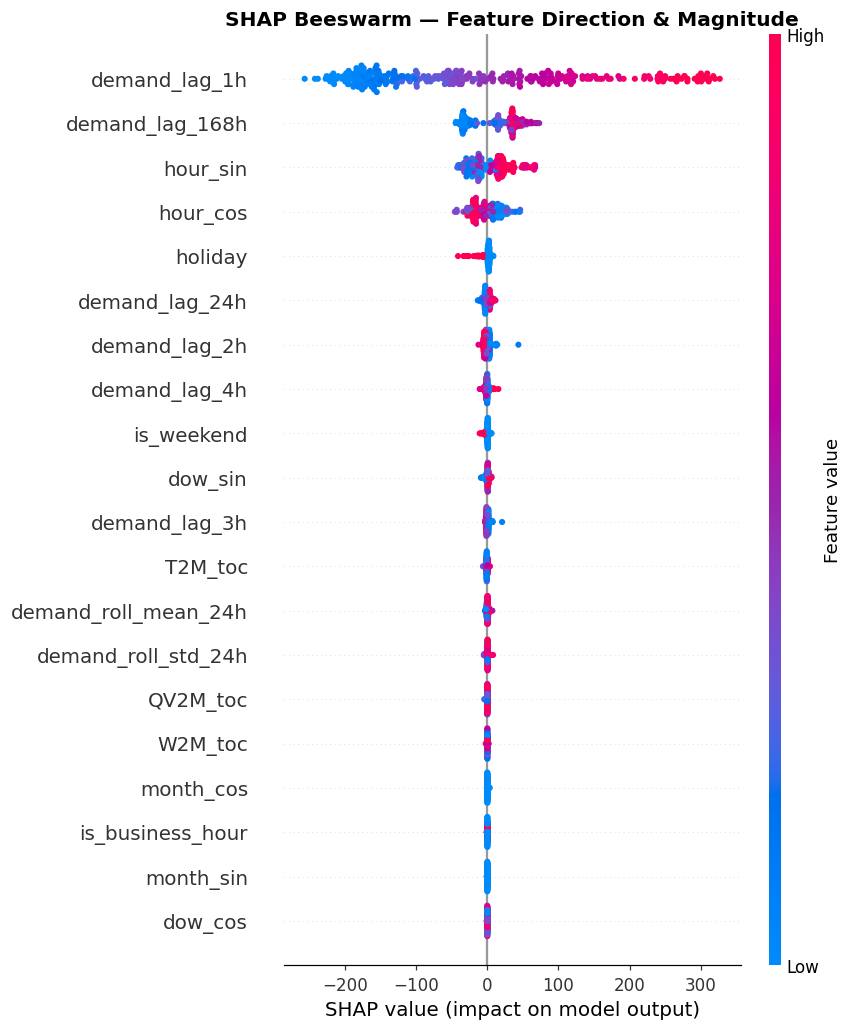

In [35]:
# ── SHAP values ───────────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(rf)
shap_sample = val_d[feature_cols].iloc[:300]
shap_values = explainer.shap_values(shap_sample)

# Bar summary
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, shap_sample, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Mean |SHAP value|', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight')
plt.show()

# Beeswarm
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, shap_sample, show=False)
plt.title('SHAP Beeswarm — Feature Direction & Magnitude', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', bbox_inches='tight')
plt.show()

## 💾 Save All Plots to Google Drive (Optional)

In [36]:
# Uncomment to save all output plots to Google Drive
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# import shutil, os
# SAVE_DIR = '/content/drive/MyDrive/electricity_forecast_outputs'
# os.makedirs(SAVE_DIR, exist_ok=True)

# ALL_PLOTS = [
#     'eda_overview.png', 'eda_seasonality.png', 'eda_distribution.png', 'eda_acf_pacf.png',
#     'cv_splits_year.png', 'grid_search.png',
#     'eval_per_fold.png', 'eval_mae_mape.png',
#     'forecast_test.png', 'residuals_test.png',
#     # Multi-horizon on TEST (6h / 12h / 24h)
#     'horizon_degradation_all.png', 'horizon_comparison_6_12_24.png', 'horizon_heatmap.png',
#     'exog_comparison.png', 'wilcoxon_plot.png',
#     'overfitting_analysis.png', 'error_analysis.png',
#     'feature_importance.png', 'shap_bar.png', 'shap_beeswarm.png',
# ]
# for f in ALL_PLOTS:
#     if os.path.exists(f):
#         shutil.copy(f, SAVE_DIR); print(f'✅ {f}')
#     else:
#         print(f'⚠️  Not found: {f}')

print('Uncomment the block above to save all plots to Drive.')


Uncomment the block above to save all plots to Drive.


## 📊 Final Summary

### Forecasting goal recap
| | |
|---|---|
| **Horizons** | **6 h / 12 h / 24 h** seq2seq forecasts (all steps at once) |
| **History** | 24 h lookback window |
| **Comparison** | 6h vs 12h vs 24h: how does accuracy degrade across the daily cycle? |
| **Validation** | **4-fold** year-based expanding window (walk-forward) |
| **Final test** | Held-out **2020 Jan–Feb**, never seen during CV or grid search |

### Data splits
| Fold | Train | Validate | Role |
|---|---|---|---|
| CV1 | 2015 | 2016 | Model selection |
| CV2 | 2015–2016 | 2017 | Model selection |
| CV3 | 2015–2017 | 2018 | Model selection |
| CV4 | 2015–2018 | 2019 | Model selection |
| **TEST** | **2015–2019** | **2020 (Jan–Feb)** | **Held-out final evaluation** |

---
### Cross-validation results — fill in after Step 8 (CV1–CV4 average)

| Model | Type | Avg RMSE | Avg MAE | Avg MAPE (%) |
|---|---|---|---|---|
| Persistence (naïve) | Baseline | | | |
| Seasonal naïve (lag-24) | Baseline | | | |
| ARIMA(2,1,2) | Statistical | | | |
| SARIMA (best from grid) | Statistical | | | |
| SARIMAX (best + exog) | Statistical | | | |

---
### Held-out TEST results (2020 Jan–Feb) — fill in after Step 8

| Model | RMSE | MAE | MAPE (%) |
|---|---|---|---|
| Persistence | | | |
| SeasonalNaive | | | |
| ARIMA | | | |
| SARIMA | | | |
| SARIMAX | | | |

---
### Horizon comparison on TEST — fill in after Step 9

| Model | 6 h RMSE | 12 h RMSE | 24 h RMSE | 6 h MAPE | 12 h MAPE | 24 h MAPE |
|---|---|---|---|---|---|---|
| Persistence | | | | | | |
| SeasonalNaive | | | | | | |
| SARIMA | | | | | | |
| SARIMAX | | | | | | |

---
### Model justification summary
- **Persistence** — naïve lower bar; any useful model must beat it
- **Seasonal naïve (lag-24)** — strong "free" baseline that captures the daily cycle with zero fitting
- **ARIMA** — trend/autocorrelation only; ignores daily seasonality → expected higher error than SARIMA
- **SARIMA** — adds s=24 seasonal structure → captures dominant daily cycle
- **SARIMAX** — adds weather + calendar exogenous → tests whether external drivers reduce residual error

---
### Methodology checklist ✅
- [x] Clear EDA with plots and statistical summaries (ADF, ACF/PACF) — Step 1
- [x] Feature engineering: lag, cyclical, rolling, differencing — Step 3
- [x] Walk-forward validation with year-based expanding window (4 folds) — Step 4
- [x] Separate held-out test set (2020 Jan–Feb) — Step 4
- [x] Appropriate baselines: Persistence + Seasonal naïve — Steps 5, 7
- [x] Multiple evaluation metrics: RMSE, MAE, MAPE — Steps 8, 9
- [x] Analysis across different forecasting horizons (6 h, 12 h, 24 h) — Step 9
- [x] Overfitting analysis: training vs validation RMSE gap per fold — Step 12

---
> **Next step:** Replace SARIMA/SARIMAX with deep learning (LSTM / GRU / TCN / Seq2Seq Transformer)
> using the **same 4-fold year-based CV splits**, **same held-out 2020 test set**, and
> **same 6h / 12h / 24h horizon evaluation**. Switch Colab to **GPU** runtime before training.
